In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd C:\Users\user\Desktop\4months
%pwd

C:\Users\user\Desktop\4months


'C:\\Users\\user\\Desktop\\4months'

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 733.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 174.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00


VERIFICACIÓN DE GPU
✅ GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Forma original del dataset: (177121, 8)
Columnas: ['id', 'date', 'hours', 'minutes', 'temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']
Columna 'id' eliminada
Características de entrada: ['date', 'hours', 'minutes']
Variables a predecir:       ['temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']
Output shape: (177121, 4) | Features shape: (177121, 3)
Longitud de secuencia: 60 puntos
X_data shape:     (177061, 60, 4)
X_features shape: (177061, 3)
y shape:          (177061, 4)
Datos desarrollo (train+val): 141648
Datos test final:             35413

CROSS-VALIDATION TEMPORAL — 3 FOLDS

────────────────────────────────────────────────────────────
  Arquitectura: Conv1D_Simple
────────────────────────────────────────────────────────────

  ► Fold 1/3 | train=35412 | val=35412
Epoch 1/30
1107/1107 [==============================] - 459s 6ms/step - loss: 0.0151

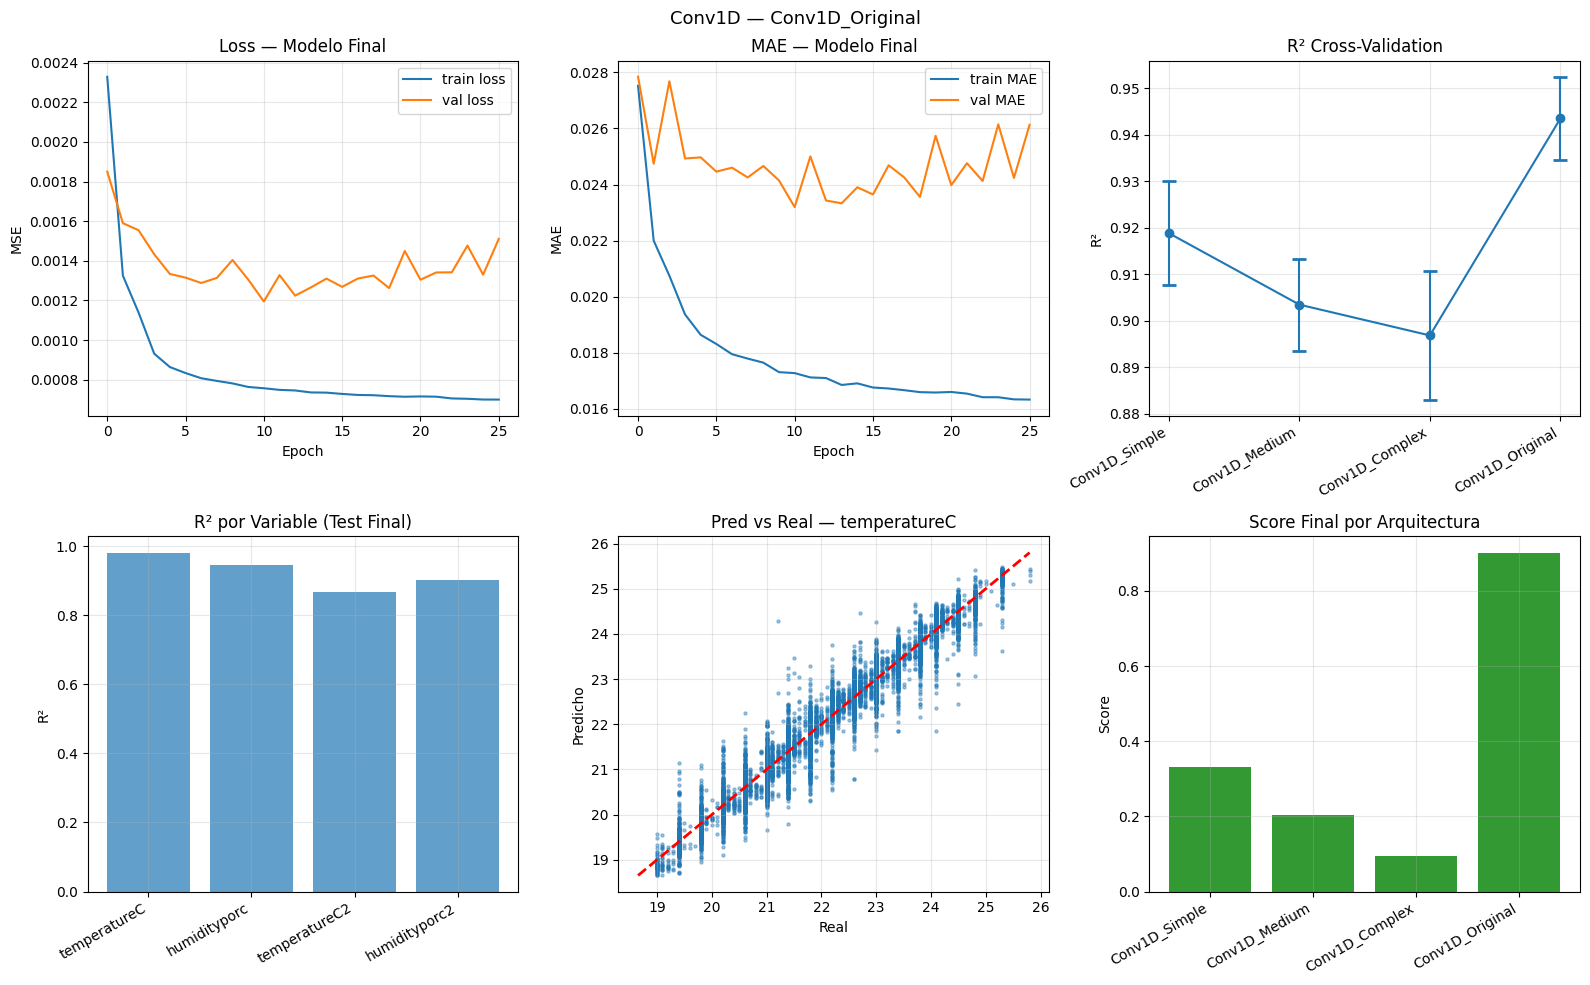

✅ Gráfica guardada en: training_logs/resultados_conv1d.png

🎉 PROCESO COMPLETADO
✅ Seed global:             SEED = 42
✅ Cross-validation:        3 folds — arquitecturas comparadas
✅ Ranking:                 cv_logs/ranking_arquitecturas.txt
✅ Mejor arquitectura:      Conv1D_Original
✅ Modelo final:            best_conv1d_model_final.h5
✅ Log entrenamiento final:  training_logs/final_training_log.txt
✅ Métricas finales:        training_logs/final_metrics.txt

📝 Uso de predict_sensors_data_conv1d:
   recent_data = df[output_features_cols].iloc[-60:].values
   pred = predict_sensors_data_conv1d(recent_data, '2026-05-03', 20, 0)

🔮 Ejemplo de predicción (2026-05-03 20:00):
   temperatureC: 22.9565
   humidityporc: 52.2513
   temperatureC2: 21.3909
   humidityporc2: 53.7010


In [2]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Conv1D, Flatten, Concatenate, Input, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
import matplotlib.pyplot as plt
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 0. SEED GLOBAL PARA REPRODUCIBILIDAD
# ==============================

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# 0.1 VERIFICAR GPU
# ==============================

print("=" * 60)
print("VERIFICACIÓN DE GPU")
print("=" * 60)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detectada: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  TensorFlow NO detecta GPU. Se usará CPU.")
print("=" * 60)

# ==============================
# 1. CARGAR Y PREPARAR DATOS
# ==============================

url = 'C:/Users/user/Desktop/4months/dataclean_4months.csv'
df = pd.read_csv(url)

print(f"Forma original del dataset: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Columna 'id' eliminada")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df['day_of_week']  = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['month']        = df['date'].dt.month
df['year']         = df['date'].dt.year

# Convertir date a ordinal (igual que MLP original)
df['date'] = df['date'].apply(lambda x: x.toordinal())

input_features_cols  = ['date', 'hours', 'minutes']
output_features_cols = ['temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']

print(f"Características de entrada: {input_features_cols}")
print(f"Variables a predecir:       {output_features_cols}")

missing_cols = [c for c in input_features_cols + output_features_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Columnas faltantes en el CSV: {missing_cols}")

# ==============================
# 2. NORMALIZACIÓN
# ==============================

scaler_output   = MinMaxScaler()
scaler_features = MinMaxScaler()

output_scaled   = scaler_output.fit_transform(df[output_features_cols])
features_scaled = scaler_features.fit_transform(df[input_features_cols])

print(f"Output shape: {output_scaled.shape} | Features shape: {features_scaled.shape}")

# ==============================
# 3. CREAR SECUENCIAS
# ==============================

def create_sequences_multi_output(data, features, seq_length):
    X_data, X_features, y = [], [], []
    for i in range(len(data) - seq_length):
        X_data.append(data[i:i + seq_length])
        X_features.append(features[i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X_data), np.array(X_features), np.array(y)

SEQ_LENGTH = 60
print(f"Longitud de secuencia: {SEQ_LENGTH} puntos")

X_data, X_features, y = create_sequences_multi_output(
    output_scaled, features_scaled, SEQ_LENGTH
)

print(f"X_data shape:     {X_data.shape}")
print(f"X_features shape: {X_features.shape}")
print(f"y shape:          {y.shape}")

# ==============================
# 4. DIVISIÓN TEMPORAL 80/20
# ==============================

split_point = int(len(X_data) * 0.8)

X_data_dev, X_features_dev, y_dev = (
    X_data[:split_point],
    X_features[:split_point],
    y[:split_point],
)
X_data_test, X_features_test, y_test = (
    X_data[split_point:],
    X_features[split_point:],
    y[split_point:],
)

print(f"Datos desarrollo (train+val): {len(X_data_dev)}")
print(f"Datos test final:             {len(X_data_test)}")

# ==============================
# 5. DIRECTORIOS DE SALIDA
# ==============================

os.makedirs("cv_logs",            exist_ok=True)
os.makedirs("cv_checkpoints",     exist_ok=True)
os.makedirs("training_logs",      exist_ok=True)
os.makedirs("training_checkpoints", exist_ok=True)

# ==============================
# 6. CONFIGURACIONES A COMPARAR
# ==============================

model_configs = {
    'Conv1D_Simple': {
        'conv_filters_1': 32, 'kernel_size_1': 5,
        'conv_filters_2': 16, 'kernel_size_2': 3,
        'conv_layers': 2,
        'dense_1': 64, 'dense_2': 32,
        'dense_layers': 2,
        'dropout_conv': 0.1, 'dropout_dense': 0.1,
        'learning_rate': 0.001,
    },
    'Conv1D_Medium': {
        'conv_filters_1': 64,  'kernel_size_1': 5,
        'conv_filters_2': 32,  'kernel_size_2': 3,
        'conv_filters_3': 16,  'kernel_size_3': 3,
        'conv_layers': 3,
        'dense_1': 128, 'dense_2': 64, 'dense_3': 32,
        'dense_layers': 3,
        'dropout_conv': 0.2, 'dropout_dense': 0.2,
        'learning_rate': 0.001,
    },
    'Conv1D_Complex': {
        'conv_filters_1': 128, 'kernel_size_1': 7,
        'conv_filters_2': 64,  'kernel_size_2': 5,
        'conv_filters_3': 32,  'kernel_size_3': 3,
        'conv_layers': 3,
        'dense_1': 256, 'dense_2': 128, 'dense_3': 64,
        'dense_layers': 3,
        'dropout_conv': 0.3, 'dropout_dense': 0.3,
        'learning_rate': 0.001,
    },
    'Conv1D_Original': {
        'conv_filters_1': 64,  'kernel_size_1': 5,
        'conv_filters_2': 32,  'kernel_size_2': 3,
        'conv_filters_3': 16,  'kernel_size_3': 3,
        'conv_layers': 3,
        'dense_1': 128, 'dense_2': 64, 'dense_3': 32,
        'dense_layers': 3,
        'dropout_conv': 0.0, 'dropout_dense': 0.0,
        'learning_rate': 0.001,
    },
}

# ==============================
# 7. FUNCIÓN PARA CREAR MODELO
# ==============================

def create_conv1d_model(seq_length, n_features_seq, n_features_static, n_outputs, config):
    data_input     = Input(shape=(seq_length, n_features_seq),  name='sequence_input')
    features_input = Input(shape=(n_features_static,),           name='features_input')

    x = Conv1D(config['conv_filters_1'], config['kernel_size_1'],
               activation='relu', padding='same')(data_input)
    if config.get('dropout_conv', 0) > 0:
        x = Dropout(config['dropout_conv'])(x)

    x = Conv1D(config['conv_filters_2'], config['kernel_size_2'],
               activation='relu', padding='same')(x)
    if config.get('dropout_conv', 0) > 0:
        x = Dropout(config['dropout_conv'])(x)

    if config.get('conv_layers', 2) > 2:
        x = Conv1D(config['conv_filters_3'], config['kernel_size_3'],
                   activation='relu', padding='same')(x)
        if config.get('dropout_conv', 0) > 0:
            x = Dropout(config['dropout_conv'])(x)

    flat   = Flatten()(x)
    concat = Concatenate()([flat, features_input])

    d = Dense(config['dense_1'], activation='relu')(concat)
    if config.get('dropout_dense', 0) > 0:
        d = Dropout(config['dropout_dense'])(d)

    d = Dense(config['dense_2'], activation='relu')(d)
    if config.get('dropout_dense', 0) > 0:
        d = Dropout(config['dropout_dense'])(d)

    if config.get('dense_layers', 2) > 2:
        d = Dense(config['dense_3'], activation='relu')(d)
        if config.get('dropout_dense', 0) > 0:
            d = Dropout(config['dropout_dense'])(d)

    output = Dense(n_outputs, activation='linear', name='prediction_output')(d)

    model = Model(inputs=[data_input, features_input], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=config.get('learning_rate', 0.001)),
        loss='mse', metrics=['mae']
    )
    return model

# ==============================
# 8. CALLBACKS PERSONALIZADOS
# ==============================

class EpochTrainingLogger(Callback):
    """
    Guarda el historial de entrenamiento época por época en un .txt,
    con el mismo formato que muestra Keras en consola.
    Soporta append para reanudación de entrenamiento.
    """
    def __init__(self, log_path, config_name, fold=None):
        super().__init__()
        self.log_path    = log_path
        self.config_name = config_name
        self.fold        = fold

    def on_train_begin(self, logs=None):
        write_header = (
            not os.path.exists(self.log_path)
            or os.path.getsize(self.log_path) == 0
        )
        if write_header:
            fold_str = f" | Fold {self.fold}" if self.fold is not None else ""
            with open(self.log_path, 'w', encoding='utf-8') as f:
                f.write("=" * 80 + "\n")
                f.write(f"TRAINING LOG — {self.config_name}{fold_str}\n")
                f.write(f"Fecha inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
                f.write("=" * 80 + "\n")
                f.write(
                    f"{'Epoch':<10} {'loss':<14} {'mae':<14} "
                    f"{'val_loss':<14} {'val_mae':<14}\n"
                )
                f.write("-" * 80 + "\n")

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        loss     = logs.get('loss',     float('nan'))
        mae      = logs.get('mae',      float('nan'))
        val_loss = logs.get('val_loss', float('nan'))
        val_mae  = logs.get('val_mae',  float('nan'))
        line = (
            f"Epoch {epoch + 1:<5} "
            f"loss={loss:.6f}  "
            f"mae={mae:.6f}  "
            f"val_loss={val_loss:.6f}  "
            f"val_mae={val_mae:.6f}\n"
        )
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write(line)

    def on_train_end(self, logs=None):
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write("-" * 80 + "\n")
            f.write(f"Entrenamiento finalizado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("=" * 80 + "\n\n")


class SaveEpochCallback(Callback):
    """Guarda el número del último epoch completado."""
    def __init__(self, epoch_path):
        super().__init__()
        self.epoch_path = epoch_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.epoch_path, 'w') as f:
            f.write(str(epoch + 1))

# ==============================
# 9. MÉTRICAS POR VARIABLE
# ==============================

def compute_metrics_per_variable(y_true_orig, y_pred_orig, output_cols):
    """Calcula MSE, RMSE, MAE, MAPE, R², correlación por variable."""
    metrics = {}
    for i, col in enumerate(output_cols):
        mse         = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse        = np.sqrt(mse)
        mae         = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        r2          = r2_score(y_true_orig[:, i], y_pred_orig[:, i])
        correlation = np.corrcoef(y_true_orig[:, i], y_pred_orig[:, i])[0, 1]
        std_true    = float(np.std(y_true_orig[:, i]))
        std_pred    = float(np.std(y_pred_orig[:, i]))

        mask = np.abs(y_true_orig[:, i]) > 1e-8
        mape = (
            np.mean(
                np.abs(
                    (y_true_orig[:, i][mask] - y_pred_orig[:, i][mask])
                    / (y_true_orig[:, i][mask] + 1e-8)
                )
            ) * 100
            if mask.sum() > 0 else 0.0
        )
        metrics[col] = dict(
            MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape,
            R2=r2, Correlation=correlation,
            STD_true=std_true, STD_pred=std_pred,
        )
    return metrics


def aggregate_metrics(per_variable_metrics):
    """
    Agrega métricas de todas las variables objetivo en valores escalares
    para usar en scoring:  mean_R2, mean_MAE, std_R2, mean_MAPE.
    """
    r2_list  = [m['R2']  for m in per_variable_metrics.values()]
    mae_list = [m['MAE'] for m in per_variable_metrics.values()]
    mean_r2  = float(np.mean(r2_list))
    std_r2   = float(np.std(r2_list))
    mean_mae = float(np.mean(mae_list))
    mean_mape = float(np.mean([m['MAPE'] for m in per_variable_metrics.values()]))
    return dict(mean_R2=mean_r2, std_R2=std_r2, mean_MAE=mean_mae, mean_MAPE=mean_mape)

# ==============================
# 10. CROSS-VALIDATION TEMPORAL 
# ==============================

N_FOLDS      = 3          # ← cambia aquí si quieres otro número de folds
CV_EPOCHS    = 30          # épocas por fold (liviano para CV)
CV_PATIENCE  = 7
BATCH_SIZE   = 32

# Archivo de progreso de CV (para reanudación)
CV_PROGRESS_FILE = "cv_logs/cv_progress.json"


def load_cv_progress():
    if os.path.exists(CV_PROGRESS_FILE):
        with open(CV_PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {}


def save_cv_progress(progress):
    with open(CV_PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)


def temporal_kfold_indices(n_samples, n_folds):
    """
    Divide los índices en n_folds bloques temporales.
    El fold i usa todos los bloques 0..i como train y el bloque i+1 como val.
    Esto simula un expanding-window CV temporal.
    """
    fold_size = n_samples // (n_folds + 1)
    splits = []
    for i in range(n_folds):
        train_end = fold_size * (i + 1)
        val_start = train_end
        val_end   = min(val_start + fold_size, n_samples)
        if val_end > val_start and train_end > 0:
            splits.append(
                (np.arange(0, train_end), np.arange(val_start, val_end))
            )
    return splits


cv_progress = load_cv_progress()
cv_results  = {}          # { config_name: { fold_metrics: [...], ... } }

print("\n" + "=" * 70)
print(f"CROSS-VALIDATION TEMPORAL — {N_FOLDS} FOLDS")
print("=" * 70)

fold_splits = temporal_kfold_indices(len(X_data_dev), N_FOLDS)

for config_name, config in model_configs.items():

    print(f"\n{'─'*60}")
    print(f"  Arquitectura: {config_name}")
    print(f"{'─'*60}")

    # Log de CV para esta arquitectura
    cv_arch_log = f"cv_logs/cv_{config_name}.txt"
    fold_metrics_list = []

    # ── Cargar progreso previo si existe ──
    prev_folds = cv_progress.get(config_name, {}).get('fold_metrics', [])
    start_fold = len(prev_folds)

    if start_fold > 0:
        fold_metrics_list = prev_folds
        print(f"  📌 Reanudando desde fold {start_fold + 1} (ya completados: {start_fold})")
    else:
        # Escribir cabecera del log de CV
        with open(cv_arch_log, 'a', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write(f"CV LOG — {config_name} — {N_FOLDS} folds\n")
            f.write(f"Fecha inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("=" * 80 + "\n\n")

    for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):

        if fold_idx < start_fold:
            continue  # Ya procesado

        fold_num = fold_idx + 1
        print(f"\n  ► Fold {fold_num}/{N_FOLDS} | train={len(train_idx)} | val={len(val_idx)}")

        # Datos de este fold
        Xd_tr, Xf_tr, y_tr = (
            X_data_dev[train_idx],
            X_features_dev[train_idx],
            y_dev[train_idx],
        )
        Xd_val, Xf_val, y_val = (
            X_data_dev[val_idx],
            X_features_dev[val_idx],
            y_dev[val_idx],
        )

        # Rutas de checkpoint y epoch para este fold
        ckpt_fold  = f"cv_checkpoints/{config_name}_fold{fold_num}.weights.h5"
        epoch_fold = f"cv_checkpoints/{config_name}_fold{fold_num}_epoch.txt"
        fold_log   = f"cv_logs/training_{config_name}_fold{fold_num}.txt"

        # Crear modelo
        tf.random.set_seed(SEED + fold_idx)
        model = create_conv1d_model(
            seq_length=SEQ_LENGTH,
            n_features_seq=X_data_dev.shape[2],
            n_features_static=X_features_dev.shape[1],
            n_outputs=len(output_features_cols),
            config=config,
        )

        # Cargar pesos previos si existen (reanudación dentro del fold)
        initial_epoch_fold = 0
        if os.path.exists(epoch_fold):
            with open(epoch_fold, 'r') as f:
                initial_epoch_fold = int(f.read().strip())
        if os.path.exists(ckpt_fold) and initial_epoch_fold > 0:
            try:
                model.load_weights(ckpt_fold)
                print(f"    ✅ Pesos cargados (epoch {initial_epoch_fold})")
            except Exception as e:
                print(f"    ⚠️  Error al cargar pesos: {e}. Iniciando desde cero.")
                initial_epoch_fold = 0

        # Callbacks
        cp_cb = ModelCheckpoint(
            filepath=ckpt_fold,
            save_weights_only=True,
            save_best_only=True,
            monitor='val_loss',
            verbose=0,
        )
        es_cb = EarlyStopping(
            monitor='val_loss',
            patience=CV_PATIENCE,
            restore_best_weights=True,
            verbose=0,
        )
        log_cb  = EpochTrainingLogger(fold_log, config_name, fold=fold_num)
        save_ep = SaveEpochCallback(epoch_fold)

        # Entrenar
        hist = model.fit(
            [Xd_tr, Xf_tr], y_tr,
            validation_data=([Xd_val, Xf_val], y_val),
            epochs=CV_EPOCHS,
            initial_epoch=initial_epoch_fold,
            batch_size=BATCH_SIZE,
            verbose=1,
            callbacks=[cp_cb, es_cb, log_cb, save_ep],
        )

        # ── Métricas del fold ──
        y_pred_s = model.predict([Xd_val, Xf_val], verbose=0)
        y_pred   = scaler_output.inverse_transform(y_pred_s)
        y_true   = scaler_output.inverse_transform(y_val)

        per_var = compute_metrics_per_variable(y_true, y_pred, output_features_cols)
        agg     = aggregate_metrics(per_var)

        # Gap = (val_MAE - train_MAE) / train_MAE  (última época)
        last_train_mae = hist.history['mae'][-1]
        last_val_mae   = hist.history['val_mae'][-1]
        gap = (last_val_mae - last_train_mae) / (last_train_mae + 1e-10)

        fold_summary = dict(
            fold=fold_num,
            mean_R2=agg['mean_R2'],
            std_R2=agg['std_R2'],
            mean_MAE=agg['mean_MAE'],
            mean_MAPE=agg['mean_MAPE'],
            gap=gap,
            train_mae_last=last_train_mae,
            val_mae_last=last_val_mae,
            per_variable=per_var,
        )
        fold_metrics_list.append(fold_summary)

        # Guardar progreso
        cv_progress[config_name] = {'fold_metrics': fold_metrics_list}
        save_cv_progress(cv_progress)

        # Escribir métricas del fold en log de CV
        with open(cv_arch_log, 'a', encoding='utf-8') as f:
            f.write(f"─── Fold {fold_num} ───\n")
            f.write(f"  mean_R2:   {agg['mean_R2']:.6f}\n")
            f.write(f"  std_R2:    {agg['std_R2']:.6f}\n")
            f.write(f"  mean_MAE:  {agg['mean_MAE']:.6f}\n")
            f.write(f"  mean_MAPE: {agg['mean_MAPE']:.4f}%\n")
            f.write(f"  Gap (val_mae-train_mae)/train_mae: {gap:.6f}\n")
            f.write(f"  Train MAE última época: {last_train_mae:.6f}\n")
            f.write(f"  Val   MAE última época: {last_val_mae:.6f}\n")
            for col, m in per_var.items():
                f.write(
                    f"    [{col}] R²={m['R2']:.4f} | MAE={m['MAE']:.4f} "
                    f"| RMSE={m['RMSE']:.4f} | MAPE={m['MAPE']:.2f}%\n"
                )
            f.write("\n")

        print(
            f"    Fold {fold_num} — R²={agg['mean_R2']:.4f} | "
            f"MAE={agg['mean_MAE']:.4f} | STD_R²={agg['std_R2']:.4f} | Gap={gap:.4f}"
        )

    # ── Estadísticas agregadas de todos los folds ──
    r2_vals  = [fm['mean_R2']  for fm in fold_metrics_list]
    mae_vals = [fm['mean_MAE'] for fm in fold_metrics_list]
    std_vals = [fm['std_R2']   for fm in fold_metrics_list]
    gap_vals = [fm['gap']      for fm in fold_metrics_list]

    cv_results[config_name] = dict(
        r2_mean=float(np.mean(r2_vals)),
        r2_std=float(np.std(r2_vals)),
        mae_mean=float(np.mean(mae_vals)),
        mae_std=float(np.std(mae_vals)),
        std_r2_mean=float(np.mean(std_vals)),
        gap_mean=float(np.mean(gap_vals)),
        fold_metrics=fold_metrics_list,
    )

    # Escribir resumen agregado en log
    agg_r2  = cv_results[config_name]['r2_mean']
    agg_std = cv_results[config_name]['std_r2_mean']
    agg_mae = cv_results[config_name]['mae_mean']
    agg_gap = cv_results[config_name]['gap_mean']

    with open(cv_arch_log, 'a', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write(f"RESUMEN AGREGADO — {config_name}\n")
        f.write(f"  Promedio R²:   {agg_r2:.6f}\n")
        f.write(f"  STD(R²):       {agg_std:.6f}\n")
        f.write(f"  Promedio MAE:  {agg_mae:.6f}\n")
        f.write(f"  Promedio Gap:  {agg_gap:.6f}\n")
        f.write("=" * 80 + "\n\n")

    print(
        f"\n  ✅ {config_name} completado — "
        f"R²={agg_r2:.4f} | STD={agg_std:.4f} | MAE={agg_mae:.4f} | Gap={agg_gap:.4f}"
    )

# ==============================
# 11. SCORING Y RANKING DE ARQUITECTURAS
# ==============================

print("\n" + "=" * 70)
print("SCORING Y RANKING DE ARQUITECTURAS")
print("=" * 70)

RANKING_LOG = "cv_logs/ranking_arquitecturas.txt"

# Recopilar métricas agregadas
names    = list(cv_results.keys())
r2_arr   = np.array([cv_results[n]['r2_mean']     for n in names])
mae_arr  = np.array([cv_results[n]['mae_mean']     for n in names])
std_arr  = np.array([cv_results[n]['std_r2_mean']  for n in names])
gap_arr  = np.array([cv_results[n]['gap_mean']     for n in names])

# ── Filtros mínimos ──
FILTER_MIN_R2  = 0.20
FILTER_MAX_GAP = 1.80
FILTER_MAX_STD = 0.15

eligible_mask = (r2_arr >= FILTER_MIN_R2) & (gap_arr <= FILTER_MAX_GAP) & (std_arr <= FILTER_MAX_STD)

def minmax_norm(arr):
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr)
    return (arr - arr.min()) / rng

# Normalizar entre arquitecturas elegibles (y todas para comparación)
r2_norm  = minmax_norm(r2_arr)
mae_norm = minmax_norm(mae_arr)
std_norm = minmax_norm(std_arr)
gap_norm = minmax_norm(gap_arr)

# Score = 0.40*R2_norm + 0.30*(1-MAE_norm) + 0.20*(1-STD_norm) + 0.10*(1-Gap_norm)
scores = (
    0.40 * r2_norm
    + 0.30 * (1 - mae_norm)
    + 0.20 * (1 - std_norm)
    + 0.10 * (1 - gap_norm)
)

# Penalizar no elegibles
scores_filtered = np.where(eligible_mask, scores, -999.0)
ranking_order   = np.argsort(scores_filtered)[::-1]

with open(RANKING_LOG, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("RANKING DE ARQUITECTURAS Conv1D — CROSS-VALIDATION\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"N_FOLDS={N_FOLDS} | FILTER: R²≥{FILTER_MIN_R2} | Gap≤{FILTER_MAX_GAP} | STD≤{FILTER_MAX_STD}\n")
    f.write("=" * 80 + "\n\n")
    f.write(
        f"{'Pos':<5} {'Arquitectura':<22} {'R²_mean':<12} {'STD_R²':<12} "
        f"{'MAE_mean':<12} {'Gap_mean':<12} {'Score':<10} {'Elegible'}\n"
    )
    f.write("-" * 90 + "\n")

    for pos, idx in enumerate(ranking_order):
        n   = names[idx]
        elig = "✅" if eligible_mask[idx] else "❌ descartada"
        line = (
            f"{pos+1:<5} {n:<22} {r2_arr[idx]:<12.6f} {std_arr[idx]:<12.6f} "
            f"{mae_arr[idx]:<12.6f} {gap_arr[idx]:<12.6f} "
            f"{scores_filtered[idx]:<10.6f} {elig}\n"
        )
        f.write(line)
        print(line, end='')

    f.write("\n" + "=" * 80 + "\n")

    # Detalles por arquitectura
    f.write("\nDETALLE POR ARQUITECTURA:\n\n")
    for idx in ranking_order:
        n    = names[idx]
        elig = eligible_mask[idx]
        f.write(f"  [{names[idx]}]  Score={scores_filtered[idx]:.6f}  {'ELEGIBLE' if elig else 'DESCARTADA'}\n")
        f.write(f"    Promedio R²:   {r2_arr[idx]:.6f}\n")
        f.write(f"    STD(R²):       {std_arr[idx]:.6f}\n")
        f.write(f"    Promedio MAE:  {mae_arr[idx]:.6f}\n")
        f.write(f"    Promedio Gap:  {gap_arr[idx]:.6f}\n")

        # Métricas por variable (promedio entre folds)
        all_vars = output_features_cols
        for col in all_vars:
            r2_folds  = [fm['per_variable'][col]['R2']  for fm in cv_results[n]['fold_metrics']]
            mae_folds = [fm['per_variable'][col]['MAE'] for fm in cv_results[n]['fold_metrics']]
            f.write(
                f"    [{col}] R²={np.mean(r2_folds):.4f}±{np.std(r2_folds):.4f} "
                f"| MAE={np.mean(mae_folds):.4f}±{np.std(mae_folds):.4f}\n"
            )
        f.write("\n")

    f.write("=" * 80 + "\n")

print(f"\n✅ Ranking guardado en: {RANKING_LOG}")

# ── Seleccionar mejor configuración ──
# El primero en ranking_order que sea elegible
best_idx = None
for idx in ranking_order:
    if eligible_mask[idx]:
        best_idx = idx
        break

if best_idx is None:
    # Si ninguna supera los filtros, tomar la de mayor R²
    print("⚠️  Ninguna arquitectura superó los filtros. Se usa la de mayor R².")
    best_idx = int(np.argmax(r2_arr))

best_config_name = names[best_idx]
best_config      = model_configs[best_config_name]

print(f"\n🏆 Mejor arquitectura seleccionada: {best_config_name}")
print(f"   Score={scores_filtered[best_idx]:.6f} | R²={r2_arr[best_idx]:.4f} | "
      f"MAE={mae_arr[best_idx]:.4f} | Gap={gap_arr[best_idx]:.4f}")

# ==============================
# 12. ENTRENAMIENTO FINAL CON TODA LA DATA DE DESARROLLO
# ==============================

print(f"\n" + "=" * 70)
print(f"ENTRENANDO MODELO FINAL — {best_config_name}")
print("=" * 70)

FINAL_EPOCHS   = 100
FINAL_PATIENCE = 15

FINAL_CKPT_PATH  = "training_checkpoints/best_conv1d_final.weights.h5"
FINAL_EPOCH_FILE = "training_checkpoints/best_conv1d_final_epoch.txt"
FINAL_LOG_PATH   = "training_logs/final_training_log.txt"
FINAL_METRICS_PATH = "training_logs/final_metrics.txt"

# División val interna (20% del dev)
val_split = int(len(X_data_dev) * 0.8)
Xd_tr_f, Xf_tr_f, y_tr_f = (
    X_data_dev[:val_split], X_features_dev[:val_split], y_dev[:val_split]
)
Xd_val_f, Xf_val_f, y_val_f = (
    X_data_dev[val_split:], X_features_dev[val_split:], y_dev[val_split:]
)

tf.random.set_seed(SEED)
final_model = create_conv1d_model(
    seq_length=SEQ_LENGTH,
    n_features_seq=X_data_dev.shape[2],
    n_features_static=X_features_dev.shape[1],
    n_outputs=len(output_features_cols),
    config=best_config,
)
final_model.summary()

# Cargar checkpoint si existe (reanudación)
initial_epoch_final = 0
if os.path.exists(FINAL_EPOCH_FILE):
    with open(FINAL_EPOCH_FILE, 'r') as f:
        initial_epoch_final = int(f.read().strip())
if os.path.exists(FINAL_CKPT_PATH) and initial_epoch_final > 0:
    try:
        final_model.load_weights(FINAL_CKPT_PATH)
        print(f"✅ Pesos cargados (epoch {initial_epoch_final}). Continuando...")
    except Exception as e:
        print(f"⚠️  No se pudo cargar checkpoint: {e}. Iniciando desde cero.")
        initial_epoch_final = 0
else:
    print("🆕 Iniciando entrenamiento final desde cero.")

cp_final  = ModelCheckpoint(
    filepath=FINAL_CKPT_PATH,
    save_weights_only=True,
    save_best_only=True,
    monitor='val_loss',
    verbose=1,
)
es_final  = EarlyStopping(
    monitor='val_loss',
    patience=FINAL_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)
log_final = EpochTrainingLogger(FINAL_LOG_PATH, best_config_name, fold=None)
ep_final  = SaveEpochCallback(FINAL_EPOCH_FILE)

history = final_model.fit(
    [Xd_tr_f, Xf_tr_f], y_tr_f,
    validation_data=([Xd_val_f, Xf_val_f], y_val_f),
    epochs=FINAL_EPOCHS,
    initial_epoch=initial_epoch_final,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[cp_final, es_final, log_final, ep_final],
)

final_model.save('best_conv1d_model_final.h5')
print("✅ Modelo final guardado: 'best_conv1d_model_final.h5'")

# ==============================
# 13. EVALUACIÓN FINAL EN TEST SET
# ==============================

print(f"\n" + "=" * 70)
print("EVALUACIÓN FINAL EN TEST SET")
print("=" * 70)

y_pred_s = final_model.predict([X_data_test, X_features_test], verbose=0)
y_pred   = scaler_output.inverse_transform(y_pred_s)
y_true   = scaler_output.inverse_transform(y_test)

per_var_final = compute_metrics_per_variable(y_true, y_pred, output_features_cols)

# Métricas de entrenamiento (última época)
all_train_loss = history.history['loss']
all_val_loss   = history.history['val_loss']
all_train_mae  = history.history['mae']
all_val_mae    = history.history['val_mae']

last_train_loss = all_train_loss[-1]
last_val_loss   = all_val_loss[-1]
last_train_mae_ = all_train_mae[-1]
last_val_mae_   = all_val_mae[-1]

gap_final = (last_val_loss - last_train_loss) / (last_train_loss + 1e-10)
std_val_loss   = float(np.std(all_val_loss))
std_train_loss = float(np.std(all_train_loss))

# Mostrar en consola
for col, m in per_var_final.items():
    print(f"\n{col}:")
    print(f"  MSE:         {m['MSE']:.4f}")
    print(f"  RMSE:        {m['RMSE']:.4f}")
    print(f"  MAE:         {m['MAE']:.4f}")
    print(f"  MAPE:        {m['MAPE']:.4f}%")
    print(f"  R²:          {m['R2']:.4f}")
    print(f"  Correlación: {m['Correlation']:.4f}")

# Escribir métricas finales en archivo
with open(FINAL_METRICS_PATH, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write(f"MÉTRICAS FINALES — {best_config_name}\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("── MÉTRICAS GLOBALES DEL ENTRENAMIENTO FINAL ──\n")
    f.write(f"  Épocas entrenadas:         {len(all_train_loss)}\n")
    f.write(f"  Train Loss (última época): {last_train_loss:.6f}\n")
    f.write(f"  Val Loss   (última época): {last_val_loss:.6f}\n")
    f.write(f"  Train MAE  (última época): {last_train_mae_:.6f}\n")
    f.write(f"  Val MAE    (última época): {last_val_mae_:.6f}\n\n")

    f.write(f"  Gap = (val_loss - train_loss) / train_loss\n")
    f.write(f"  Gap = ({last_val_loss:.6f} - {last_train_loss:.6f}) / {last_train_loss:.6f}\n")
    f.write(f"  Gap = {gap_final:.6f}  ")
    if gap_final > 0.5:
        f.write("⚠️  ALTO → posible overfitting\n")
    elif gap_final > 0.2:
        f.write("⚡ MODERADO → revisar regularización\n")
    else:
        f.write("✅ BAJO → modelo generaliza bien\n")

    f.write(f"\n  STD val_loss (estabilidad):  {std_val_loss:.6f}\n")
    f.write(f"  STD train_loss:              {std_train_loss:.6f}\n\n")

    f.write("── MÉTRICAS POR VARIABLE (test set, espacio original) ──\n\n")
    for col, m in per_var_final.items():
        f.write(f"  [{col}]\n")
        f.write(f"    R²:          {m['R2']:.6f}\n")
        f.write(f"    STD real:    {m['STD_true']:.6f}\n")
        f.write(f"    STD pred:    {m['STD_pred']:.6f}\n")
        f.write(f"    MAE:         {m['MAE']:.6f}\n")
        f.write(f"    RMSE:        {m['RMSE']:.6f}\n")
        f.write(f"    MAPE:        {m['MAPE']:.4f}%\n")
        f.write(f"    Correlación: {m['Correlation']:.6f}\n")
        f.write(f"    Gap (global modelo): {gap_final:.6f}\n\n")

    f.write("=" * 80 + "\nFIN DEL REPORTE\n" + "=" * 80 + "\n")

print(f"\n✅ Métricas finales guardadas en: {FINAL_METRICS_PATH}")

# ==============================
# 14. FUNCIÓN DE PREDICCIÓN
# ==============================

def predict_sensors_data_conv1d(recent_data, date_str, hours, minutes):
    """
    Realizar predicción con el modelo Conv1D final.

    Args:
        recent_data (np.ndarray): Últimos SEQ_LENGTH puntos de sensores sin normalizar.
                                  Shape (SEQ_LENGTH, 4)
        date_str (str): Fecha 'YYYY-MM-DD'
        hours (int):    Hora 0–23
        minutes (int):  Minuto 0–59

    Returns:
        dict: {variable: valor_predicho}
    """
    dt_obj     = datetime.strptime(date_str, '%Y-%m-%d')
    date_ord   = dt_obj.toordinal()
    temp_feat  = np.array([[date_ord, hours, minutes]])
    temp_scaled = scaler_features.transform(temp_feat)

    recent_scaled = scaler_output.transform(recent_data)
    recent_scaled = recent_scaled.reshape(1, SEQ_LENGTH, len(output_features_cols))

    pred_s = final_model.predict([recent_scaled, temp_scaled], verbose=0)
    pred   = scaler_output.inverse_transform(pred_s)[0]
    return dict(zip(output_features_cols, pred))

# ==============================
# 15. VISUALIZACIONES
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Conv1D — {best_config_name}', fontsize=13)

# 1) Loss del modelo final
ax = axes[0, 0]
ax.plot(history.history['loss'],     label='train loss')
ax.plot(history.history['val_loss'], label='val loss')
ax.set_title('Loss — Modelo Final')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)

# 2) MAE del modelo final
ax = axes[0, 1]
ax.plot(history.history['mae'],     label='train MAE')
ax.plot(history.history['val_mae'], label='val MAE')
ax.set_title('MAE — Modelo Final')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
ax.legend(); ax.grid(True, alpha=0.3)

# 3) R² por arquitectura (CV)
ax = axes[0, 2]
cfg_names = list(cv_results.keys())
r2_means  = [cv_results[n]['r2_mean'] for n in cfg_names]
r2_stds   = [cv_results[n]['r2_std']  for n in cfg_names]
ax.errorbar(range(len(cfg_names)), r2_means, yerr=r2_stds,
            marker='o', capsize=5, capthick=2)
ax.set_xticks(range(len(cfg_names)))
ax.set_xticklabels(cfg_names, rotation=30, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² Cross-Validation')
ax.grid(True, alpha=0.3)

# 4) R² por variable en test final
ax = axes[1, 0]
final_r2 = [per_var_final[c]['R2'] for c in output_features_cols]
ax.bar(output_features_cols, final_r2, alpha=0.7)
ax.set_ylabel('R²'); ax.set_title('R² por Variable (Test Final)')
ax.set_xticklabels(output_features_cols, rotation=30, ha='right')
ax.grid(True, alpha=0.3)

# 5) Predicciones vs Reales (primera variable)
ax = axes[1, 1]
ax.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.4, s=5)
lims = [min(y_true[:, 0].min(), y_pred[:, 0].min()),
        max(y_true[:, 0].max(), y_pred[:, 0].max())]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel('Real'); ax.set_ylabel('Predicho')
ax.set_title(f'Pred vs Real — {output_features_cols[0]}')
ax.grid(True, alpha=0.3)

# 6) Score por arquitectura
ax = axes[1, 2]
colors = ['green' if eligible_mask[i] else 'gray' for i in range(len(names))]
ax.bar(names, scores_filtered, color=colors, alpha=0.8)
ax.set_ylabel('Score'); ax.set_title('Score Final por Arquitectura')
ax.set_xticklabels(names, rotation=30, ha='right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs/resultados_conv1d.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en: training_logs/resultados_conv1d.png")

# ==============================
# 16. RESUMEN FINAL
# ==============================

print(f"\n🎉 PROCESO COMPLETADO")
print(f"✅ Seed global:             SEED = {SEED}")
print(f"✅ Cross-validation:        {N_FOLDS} folds — arquitecturas comparadas")
print(f"✅ Ranking:                 {RANKING_LOG}")
print(f"✅ Mejor arquitectura:      {best_config_name}")
print(f"✅ Modelo final:            best_conv1d_model_final.h5")
print(f"✅ Log entrenamiento final:  {FINAL_LOG_PATH}")
print(f"✅ Métricas finales:        {FINAL_METRICS_PATH}")
print(f"\n📝 Uso de predict_sensors_data_conv1d:")
print(f"   recent_data = df[output_features_cols].iloc[-{SEQ_LENGTH}:].values")
print(f"   pred = predict_sensors_data_conv1d(recent_data, '2026-05-03', 20, 0)")

if len(df) >= SEQ_LENGTH:
    example_data = df[output_features_cols].iloc[-SEQ_LENGTH:].values
    example_pred = predict_sensors_data_conv1d(example_data, '2026-05-03', 20, 0)
    print(f"\n🔮 Ejemplo de predicción (2026-05-03 20:00):")
    for var, val in example_pred.items():
        print(f"   {var}: {val:.4f}")

In [3]:
# Get user input for date, hours, and minutes
date_input = input("Enter the date (YYYY-MM-DD): ")
hours_input = int(input("Enter the hour (0-23): "))
minutes_input = int(input("Enter the minute (0-59): "))

# Obtener los últimos SEQ_LENGTH datos históricos
recent_data = df[output_features_cols].iloc[-SEQ_LENGTH:].values

# Use the predict_sensors_data function to get predictions
predicted_data = predict_sensors_data_conv1d(recent_data, date_input, hours_input, minutes_input)

# Print the predictions
print(f"\nPredicted data for {date_input} {hours_input:02d}:{minutes_input:02d}:")
for target, value in predicted_data.items():
    print(f"  {target}: {value:.4f}")


Predicted data for 2025-09-01 20:02:
  temperatureC: 23.3364
  humidityporc: 57.1412
  temperatureC2: 20.9398
  humidityporc2: 60.9524


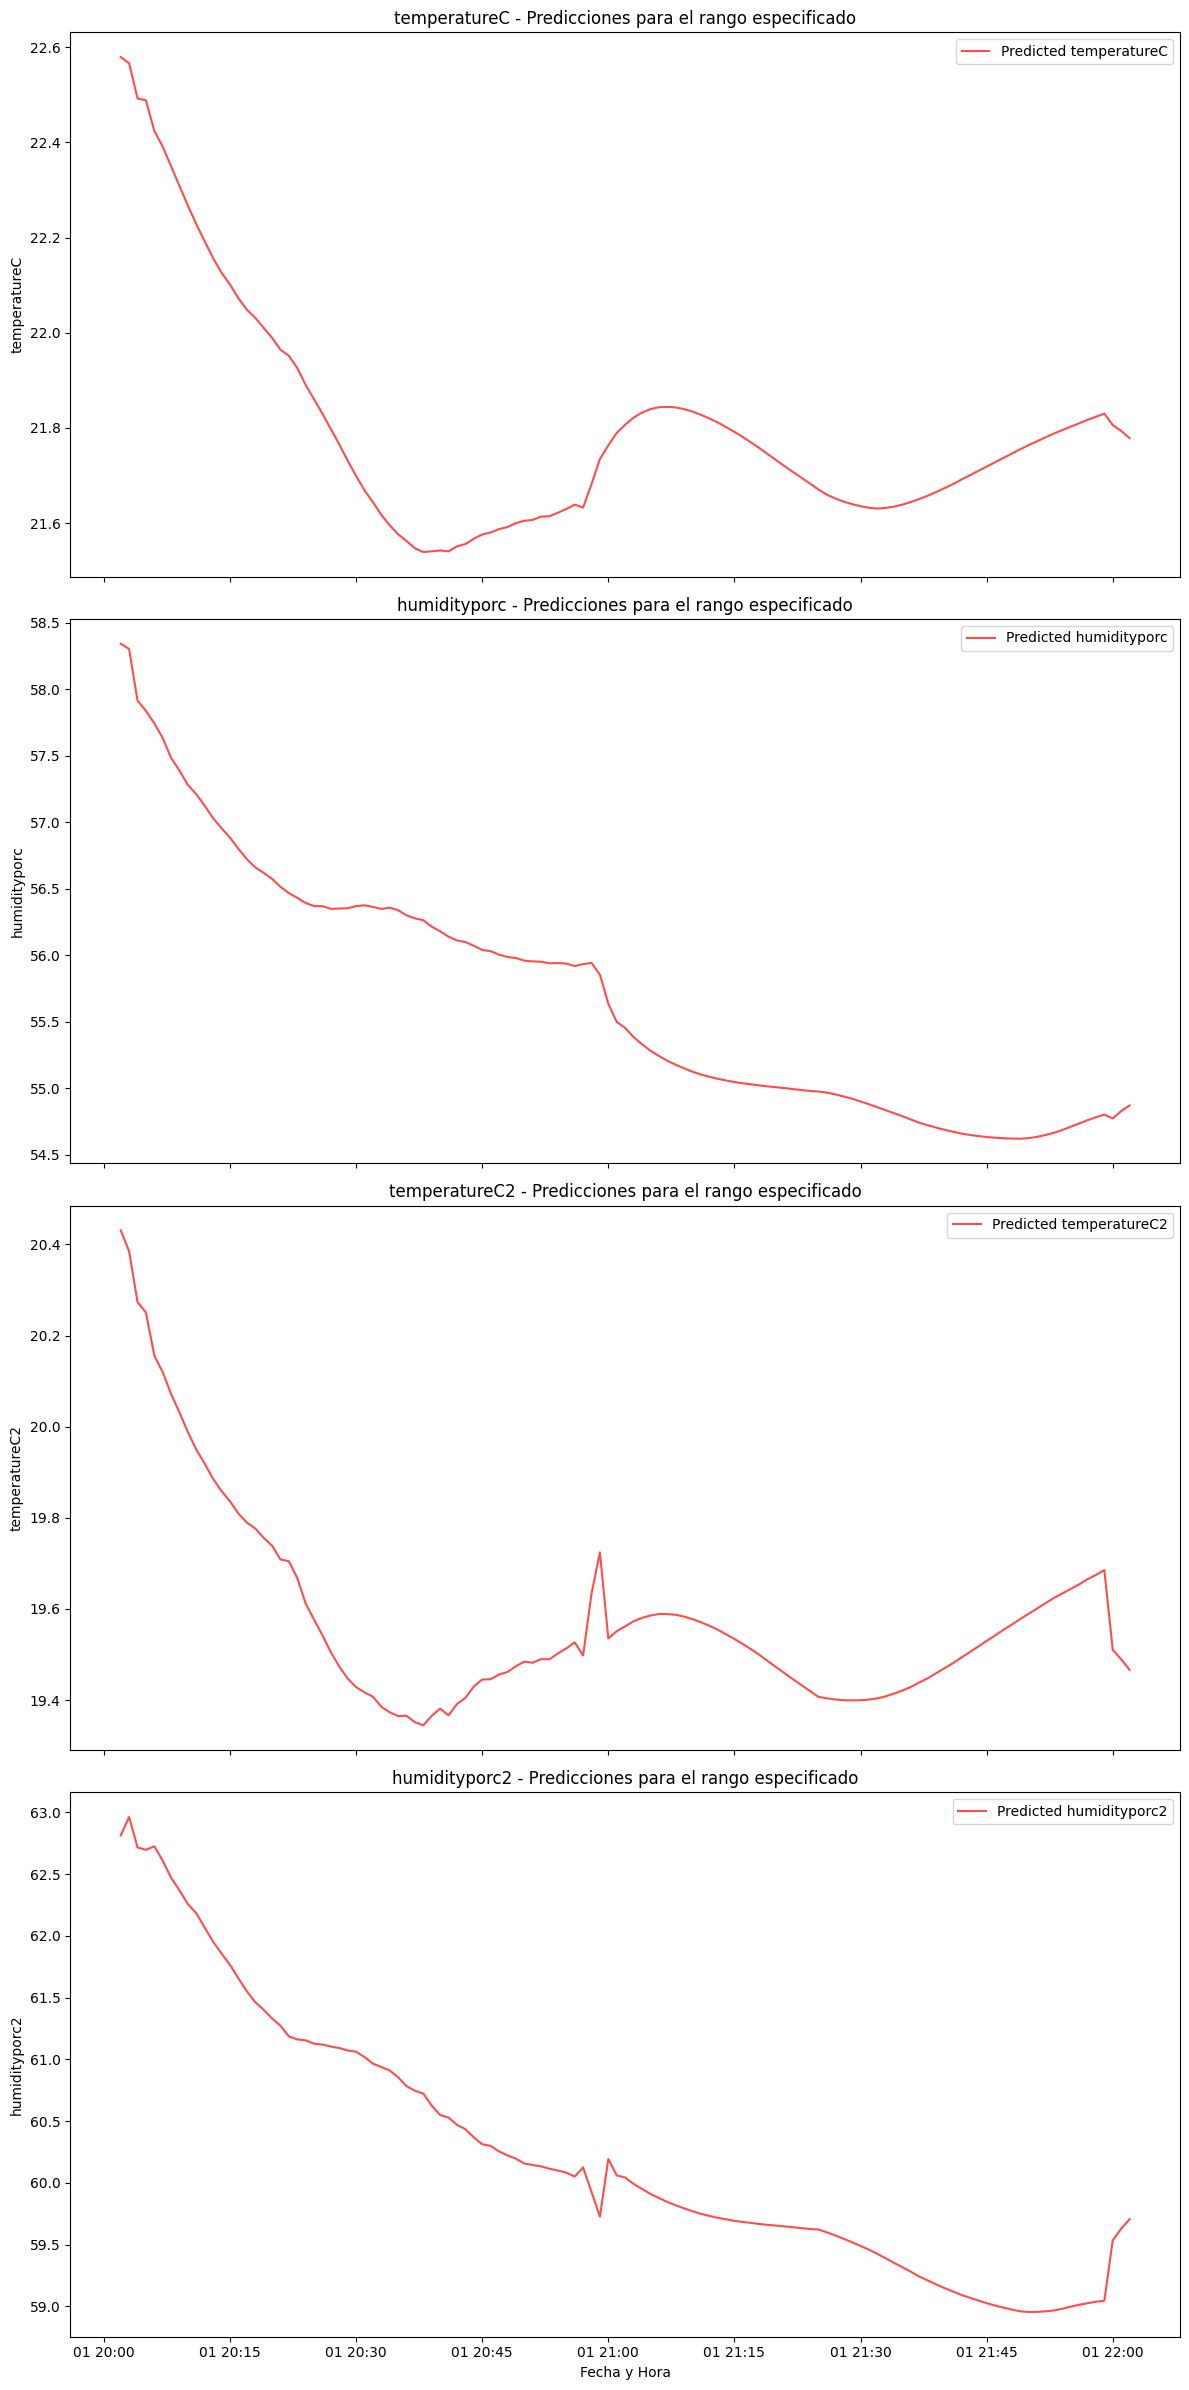

In [5]:
# Get user input for the start and end date and time
start_date_str = input("Enter the start date for prediction (YYYY-MM-DD): ")
start_hour = int(input("Enter the start hour for prediction (0-23): "))
start_minute = int(input("Enter the start minute for prediction (0-59): "))

end_date_str = input("Enter the end date for prediction (YYYY-MM-DD): ")
end_hour = int(input("Enter the end hour for prediction (0-23): "))
end_minute = int(input("Enter the end minute for prediction (0-59): "))

# Create datetime objects from user input
start_datetime = datetime.strptime(f"{start_date_str} {start_hour}:{start_minute}", '%Y-%m-%d %H:%M')
end_datetime = datetime.strptime(f"{end_date_str} {end_hour}:{end_minute}", '%Y-%m-%d %H:%M')

# Create a date range at minute frequency for prediction
dates_to_predict_range = pd.date_range(start=start_datetime, end=end_datetime, freq='min')

# Prepare temporal features for prediction
prediction_inputs = pd.DataFrame({
    'date': [d.toordinal() for d in dates_to_predict_range],
    'hours': [d.hour for d in dates_to_predict_range],
    'minutes': [d.minute for d in dates_to_predict_range]
})

# Hacer predicciones para cada punto en el tiempo
predictions_list = []

# Usar los últimos seq_length datos del dataset como punto de partida
recent_data = df[output_features_cols].iloc[-SEQ_LENGTH:].values

for idx, row in prediction_inputs.iterrows():
    # Normalizar características temporales
    temporal_features = np.array([[row['date'], row['hours'], row['minutes']]])
    temporal_features_scaled = scaler_features.transform(temporal_features)

    # Normalizar datos recientes
    recent_data_scaled = scaler_output.transform(recent_data)
    recent_data_scaled = recent_data_scaled.reshape(1, SEQ_LENGTH, len(output_features_cols))

    # Predecir
    prediction_scaled = model.predict([recent_data_scaled, temporal_features_scaled], verbose=0)
    prediction = scaler_output.inverse_transform(prediction_scaled)[0]

    predictions_list.append(prediction)

    # Actualizar recent_data con la nueva predicción (rolling window)
    recent_data = np.vstack([recent_data[1:], prediction])

# Crear DataFrame con las predicciones
predictions_df = pd.DataFrame(predictions_list, index=dates_to_predict_range, columns=output_features_cols)

# Plotting the predictions
fig, axes = plt.subplots(len(output_features_cols), 1, figsize=(12, 6 * len(output_features_cols)), sharex=True)

for i, target in enumerate(output_features_cols):
    axes[i].plot(predictions_df.index, predictions_df[target], label=f'Predicted {target}', color='red', alpha=0.7)
    axes[i].set_title(f'{target} - Predicciones para el rango especificado')
    axes[i].set_ylabel(target)
    axes[i].legend()

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()

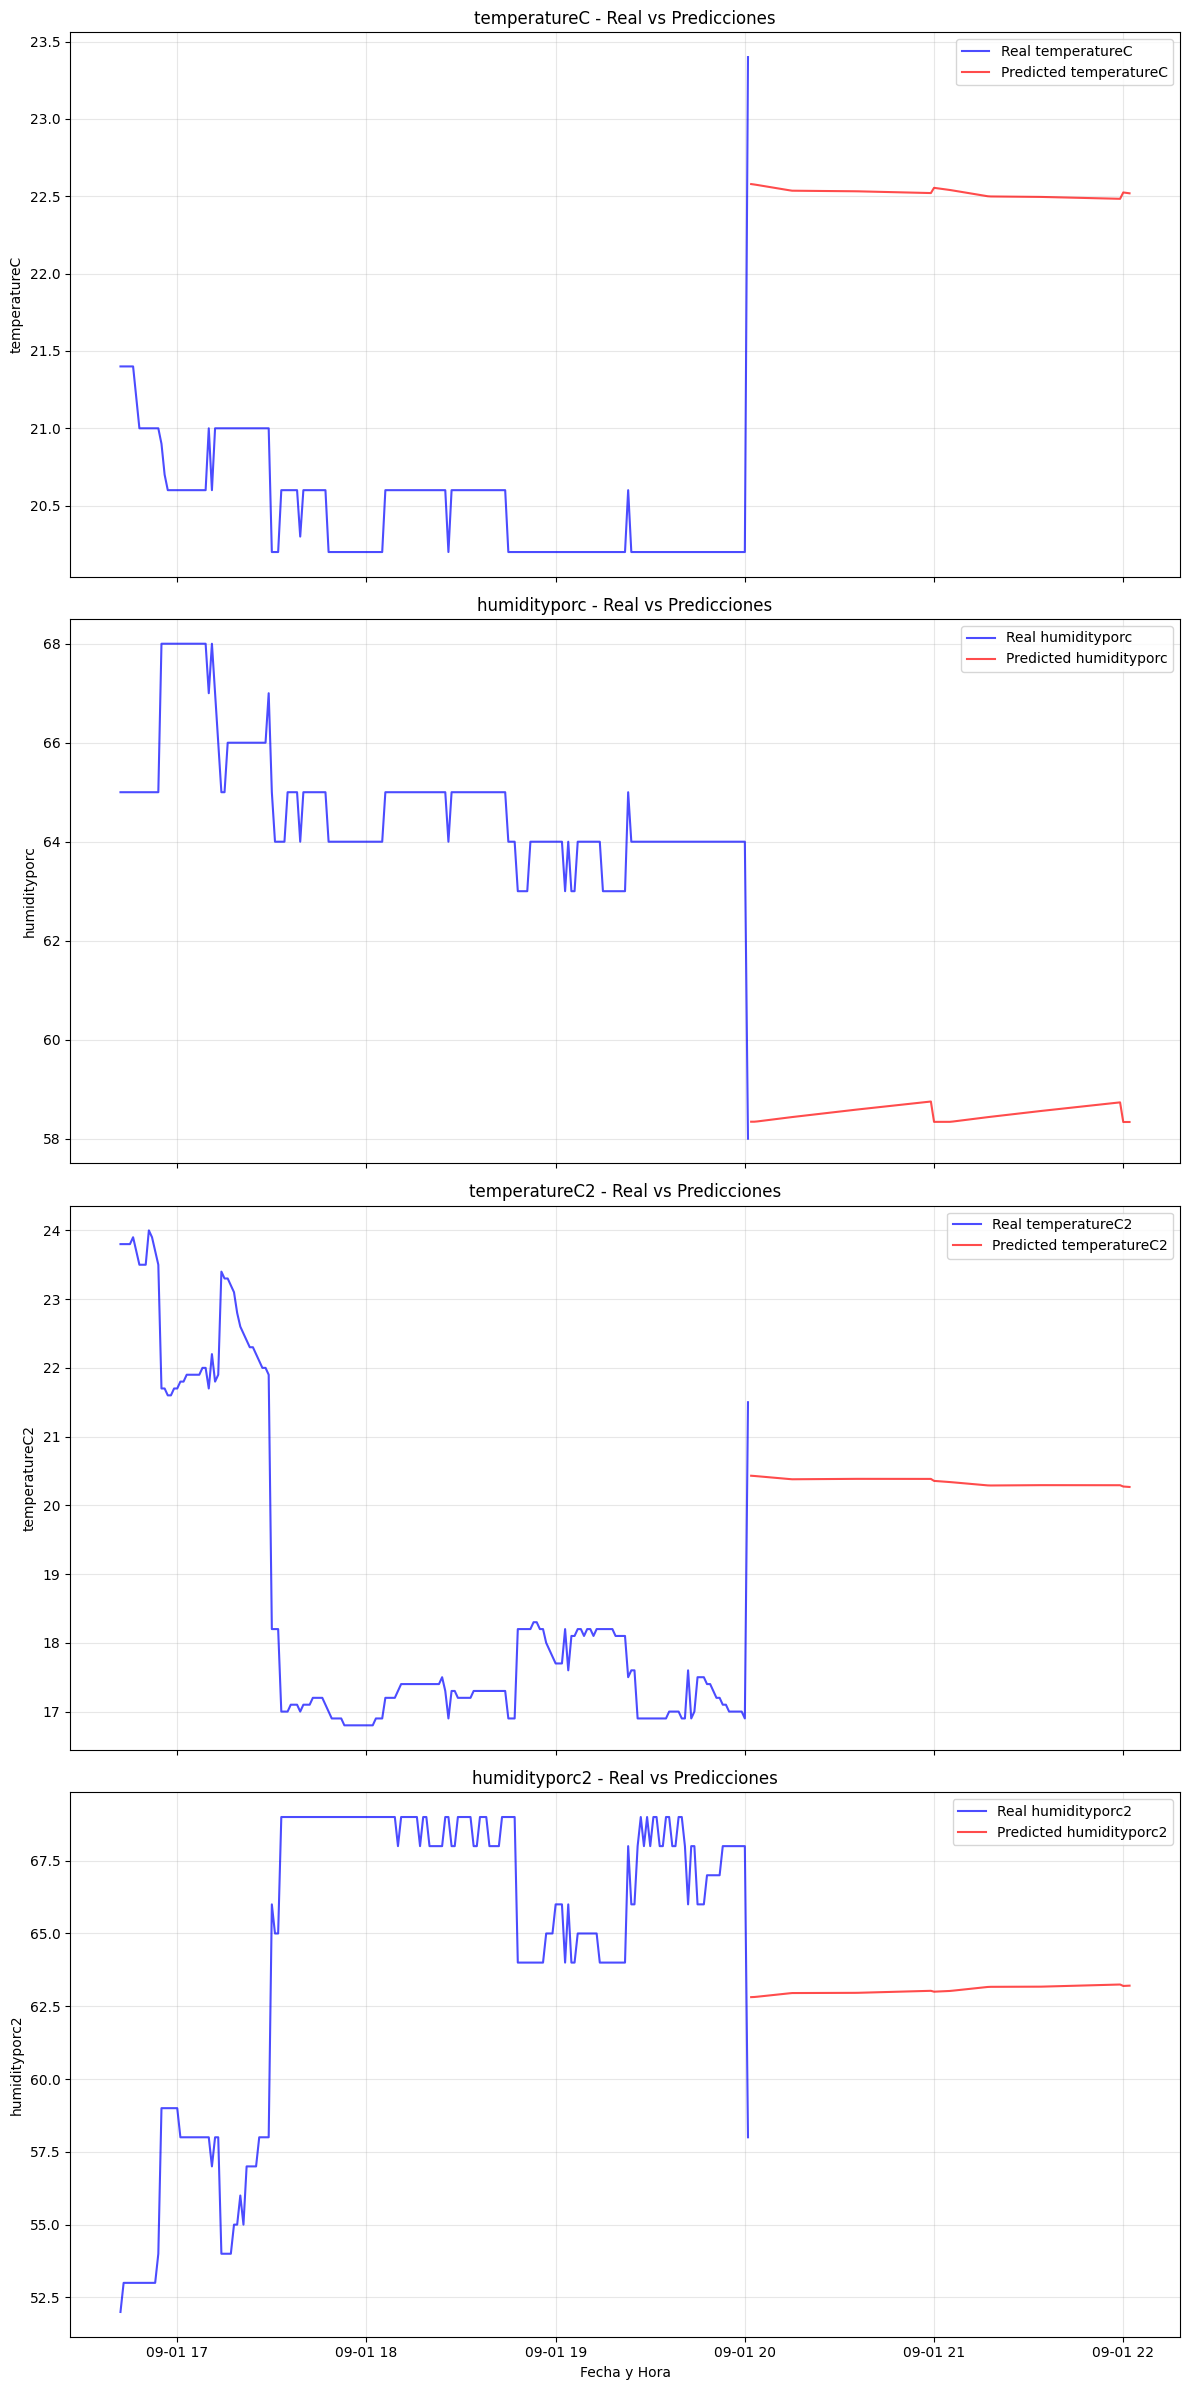

In [6]:
from datetime import timedelta  # Asegúrate de tener este import

# Get user input for the start and end date and time for predictions
start_date_str = input("Enter the start date for prediction (YYYY-MM-DD): ")
start_hour = int(input("Enter the start hour for prediction (0-23): "))
start_minute = int(input("Enter the start minute for prediction (0-59): "))

end_date_str = input("Enter the end date for prediction (YYYY-MM-DD): ")
end_hour = int(input("Enter the end hour for prediction (0-23): "))
end_minute = int(input("Enter the end minute for prediction (0-59): "))

# Create datetime objects from user input
start_datetime_pred = datetime.strptime(f"{start_date_str} {start_hour}:{start_minute}", '%Y-%m-%d %H:%M')
end_datetime_pred = datetime.strptime(f"{end_date_str} {end_hour}:{end_minute}", '%Y-%m-%d %H:%M')

# Create a date range at minute frequency for prediction
dates_to_predict_range = pd.date_range(start=start_datetime_pred, end=end_datetime_pred, freq='min')

# Prepare input data for prediction
prediction_inputs = pd.DataFrame({
    'date': [d.toordinal() for d in dates_to_predict_range],
    'hours': [d.hour for d in dates_to_predict_range],
    'minutes': [d.minute for d in dates_to_predict_range]
})

# Usar los últimos seq_length datos REALES del dataset como contexto histórico
recent_data = df[output_features_cols].iloc[-SEQ_LENGTH:].values

# Hacer predicciones para todo el rango
predictions_list = []

for idx, row in prediction_inputs.iterrows():
    temporal_features = np.array([[row['date'], row['hours'], row['minutes']]])
    temporal_features_scaled = scaler_features.transform(temporal_features)

    recent_data_scaled = scaler_output.transform(recent_data)
    recent_data_scaled = recent_data_scaled.reshape(1, SEQ_LENGTH, len(output_features_cols))

    prediction_scaled = model.predict([recent_data_scaled, temporal_features_scaled], verbose=0)
    prediction = scaler_output.inverse_transform(prediction_scaled)[0]

    predictions_list.append(prediction)

predictions_df = pd.DataFrame(predictions_list, index=dates_to_predict_range, columns=output_features_cols)

# Get the last 200 real data points
last_200_real_data = df[output_features_cols].iloc[-200:].copy()

# Crear índice datetime que termine justo antes de las predicciones
last_200_datetime_index = pd.date_range(end=start_datetime_pred - timedelta(minutes=1), periods=200, freq='min')
last_200_real_data.index = last_200_datetime_index

# Plotting
fig, axes = plt.subplots(len(output_features_cols), 1, figsize=(12, 6 * len(output_features_cols)), sharex=True)

if len(output_features_cols) == 1:
    axes = [axes]

for i, target in enumerate(output_features_cols):
    axes[i].plot(last_200_real_data.index, last_200_real_data[target],
                 label=f'Real {target}', alpha=0.7, color='blue', linewidth=1.5)
    axes[i].plot(predictions_df.index, predictions_df[target],
                 label=f'Predicted {target}', color='red', alpha=0.7, linewidth=1.5)
    axes[i].set_title(f'{target} - Real vs Predicciones')
    axes[i].set_ylabel(target)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()

✅ Modelo cargado correctamente
Orden temporal correcto: True


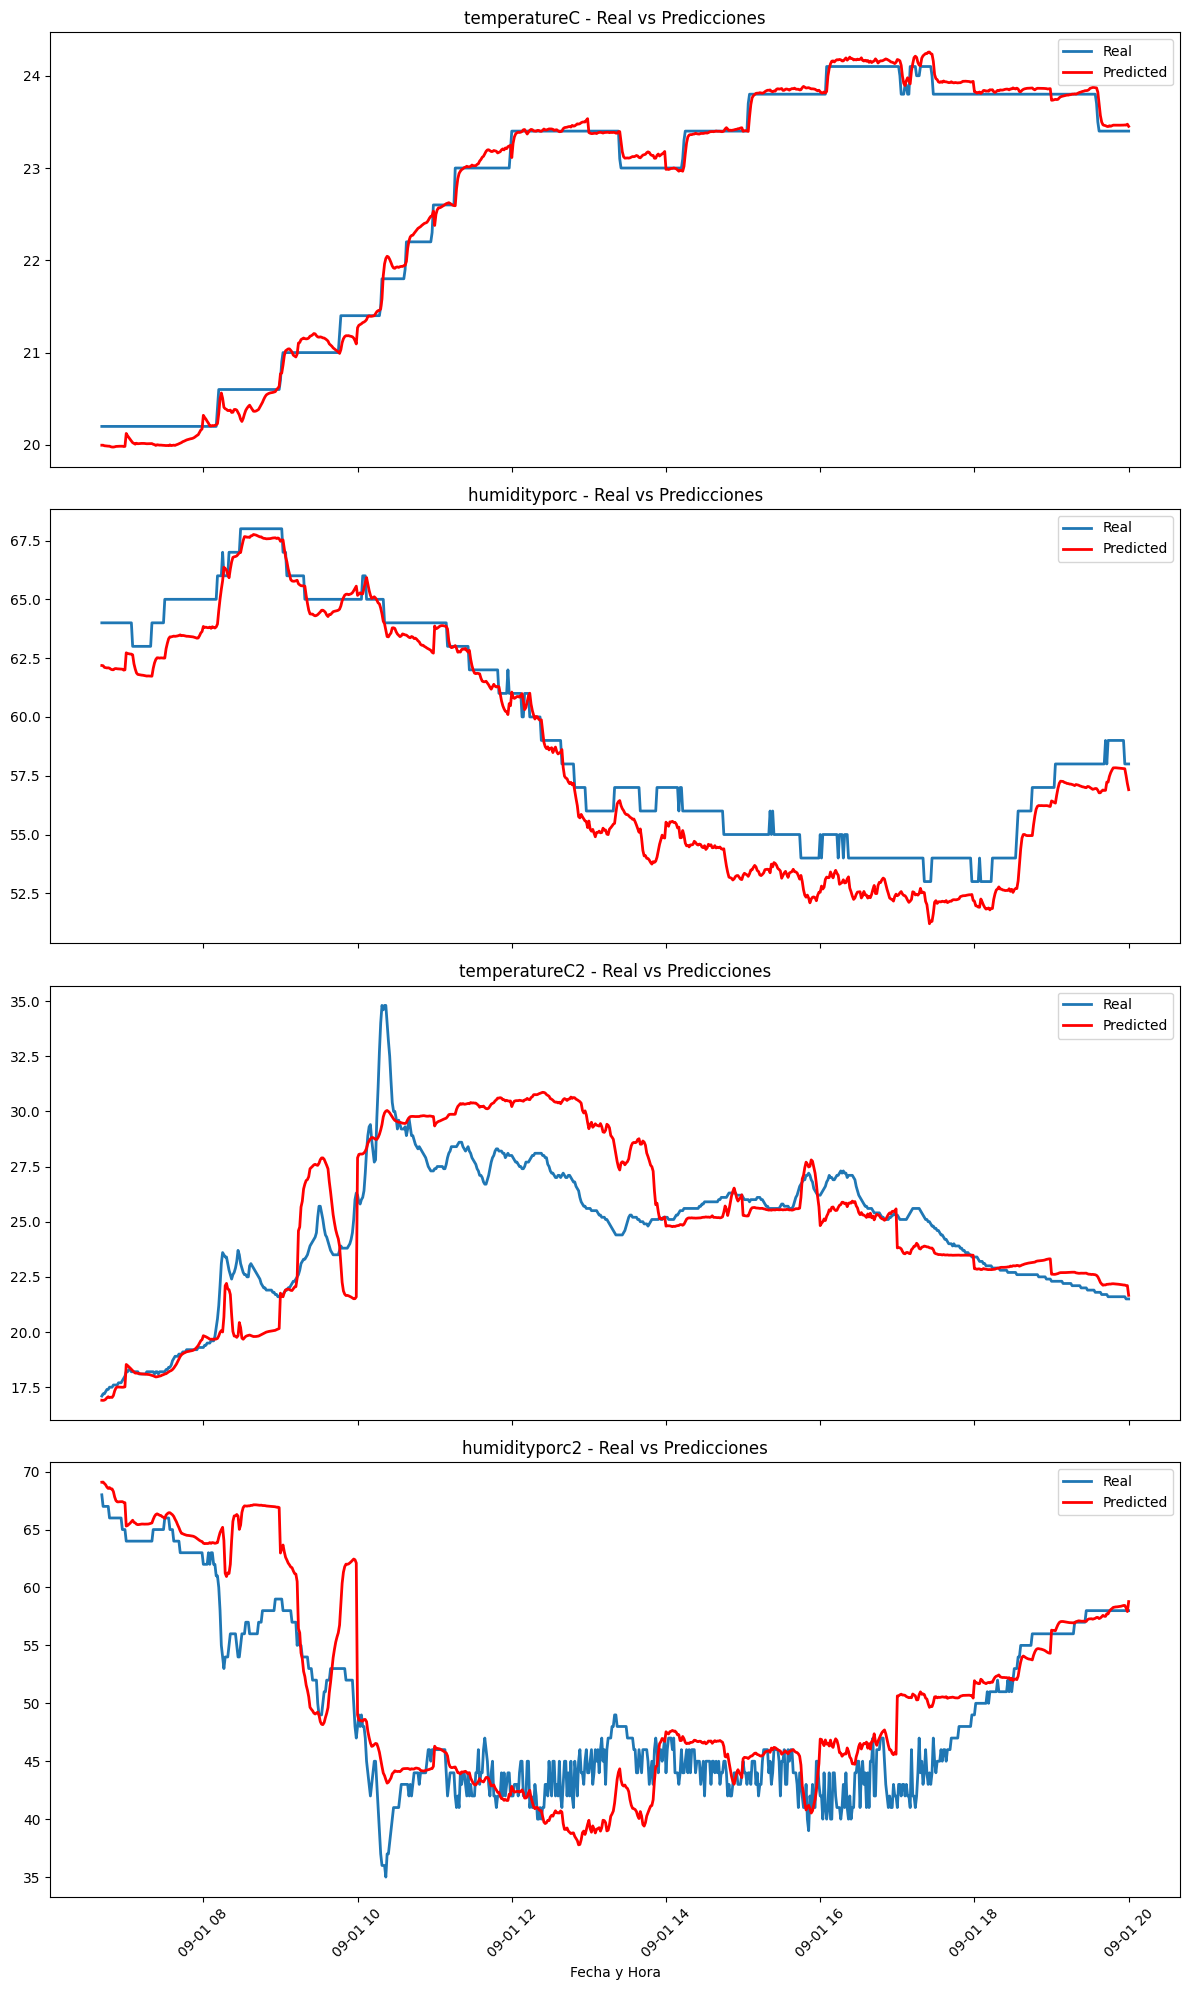

In [7]:
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ======================
# 1. Cargar modelo entrenado
# ======================

model_path = r"C:\Users\user\Desktop\4months\1D\best_conv1d_model_final.h5"
model = load_model(model_path, compile=False)

print("✅ Modelo cargado correctamente")

# ======================
# 2. Cargar dataset
# ======================

url = r"C:\Users\user\Desktop\4months\dataclean_4months.csv"
df = pd.read_csv(url)

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Convertir fecha correctamente
df['date'] = pd.to_datetime(df['date'])

# Crear datetime REAL para graficar
df['datetime_real'] = (
    df['date']
    + pd.to_timedelta(df['hours'], unit='h')
    + pd.to_timedelta(df['minutes'], unit='m')
)

# 🔥 ORDEN TEMPORAL DEFINITIVO (SOLO UNA VEZ)
df = df.sort_values('datetime_real').reset_index(drop=True)

# Convertir date a ordinal SOLO como feature del modelo
df['date'] = df['date'].apply(lambda x: x.toordinal())

# Verificación opcional
print("Orden temporal correcto:", df['datetime_real'].is_monotonic_increasing)

# ======================
# 3. Columnas usadas
# ======================

input_features_cols = ['date', 'hours', 'minutes']
output_features_cols = [
    'temperatureC',
    'humidityporc',
    'temperatureC2',
    'humidityporc2'
]

# ======================
# 4. Escaladores (IGUAL entrenamiento)
# ======================

scaler_output = MinMaxScaler()
scaler_features = MinMaxScaler()

output_scaled = scaler_output.fit_transform(df[output_features_cols])
features_scaled = scaler_features.fit_transform(df[input_features_cols])

# ======================
# 5. Crear secuencias
# ======================

seq_length = 60

def create_sequences(data, features, seq_length):
    X_data, X_features, y = [], [], []

    for i in range(len(data) - seq_length):
        X_data.append(data[i:i+seq_length])
        X_features.append(features[i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X_data), np.array(X_features), np.array(y)

X_data, X_features, y = create_sequences(output_scaled, features_scaled, seq_length)

# Fechas alineadas con secuencias
dates_seq = df['datetime_real'].iloc[seq_length:].reset_index(drop=True)

# ======================
# 6. Predicciones
# ======================

pred_scaled = model.predict([X_data, X_features], verbose=0)
pred = scaler_output.inverse_transform(pred_scaled)
y_true = scaler_output.inverse_transform(y)

# ======================
# 7. Visualización temporal correcta
# ======================

subset = 800

fig, axes = plt.subplots(
    len(output_features_cols),
    1,
    figsize=(12, 5 * len(output_features_cols)),
    sharex=True
)

for i, target in enumerate(output_features_cols):

    axes[i].plot(
        dates_seq[-subset:],
        y_true[-subset:, i],
        label="Real",
        linewidth=2
    )

    axes[i].plot(
        dates_seq[-subset:],
        pred[-subset:, i],
        label="Predicted",
        linewidth=2,
        color='red'
    )

    axes[i].set_title(f"{target} - Real vs Predicciones")
    axes[i].legend()
    #axes[i].grid(True)

plt.xticks(rotation=45)
axes[-1].set_xlabel("Fecha y Hora")

plt.tight_layout()
plt.show()


INICIANDO EVALUACIÓN DETALLADA DEL MODELO CONV1D
EVALUACIÓN DEL MODELO CONV1D - SENSORES
Realizando predicciones en conjunto de prueba...
Invirtiendo normalización...
Shape de predicciones: (35413, 4)
Shape de valores reales: (35413, 4)
Número de muestras de prueba: 35413
Variables objetivo: ['temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']

MÉTRICAS DE RENDIMIENTO

Métricas para temperatureC:
----------------------------------------
  MSE: 0.0451
  RMSE: 0.2123
  MAE: 0.1410
  MAPE: 0.6408%
  R²: 0.9789
  Correlación: 0.9903
  Media real vs pred: 22.2778 vs 22.2653
  Std real vs pred: 1.4624 vs 1.5093

Métricas para humidityporc:
----------------------------------------
  MSE: 1.2038
  RMSE: 1.0972
  MAE: 0.8150
  MAPE: 1.3721%
  R²: 0.9441
  Correlación: 0.9797
  Media real vs pred: 60.0519 vs 59.5015
  Std real vs pred: 4.6419 vs 4.7383

Métricas para temperatureC2:
----------------------------------------
  MSE: 2.6371
  RMSE: 1.6239
  MAE: 0.9491
  MAPE: 3.9939%


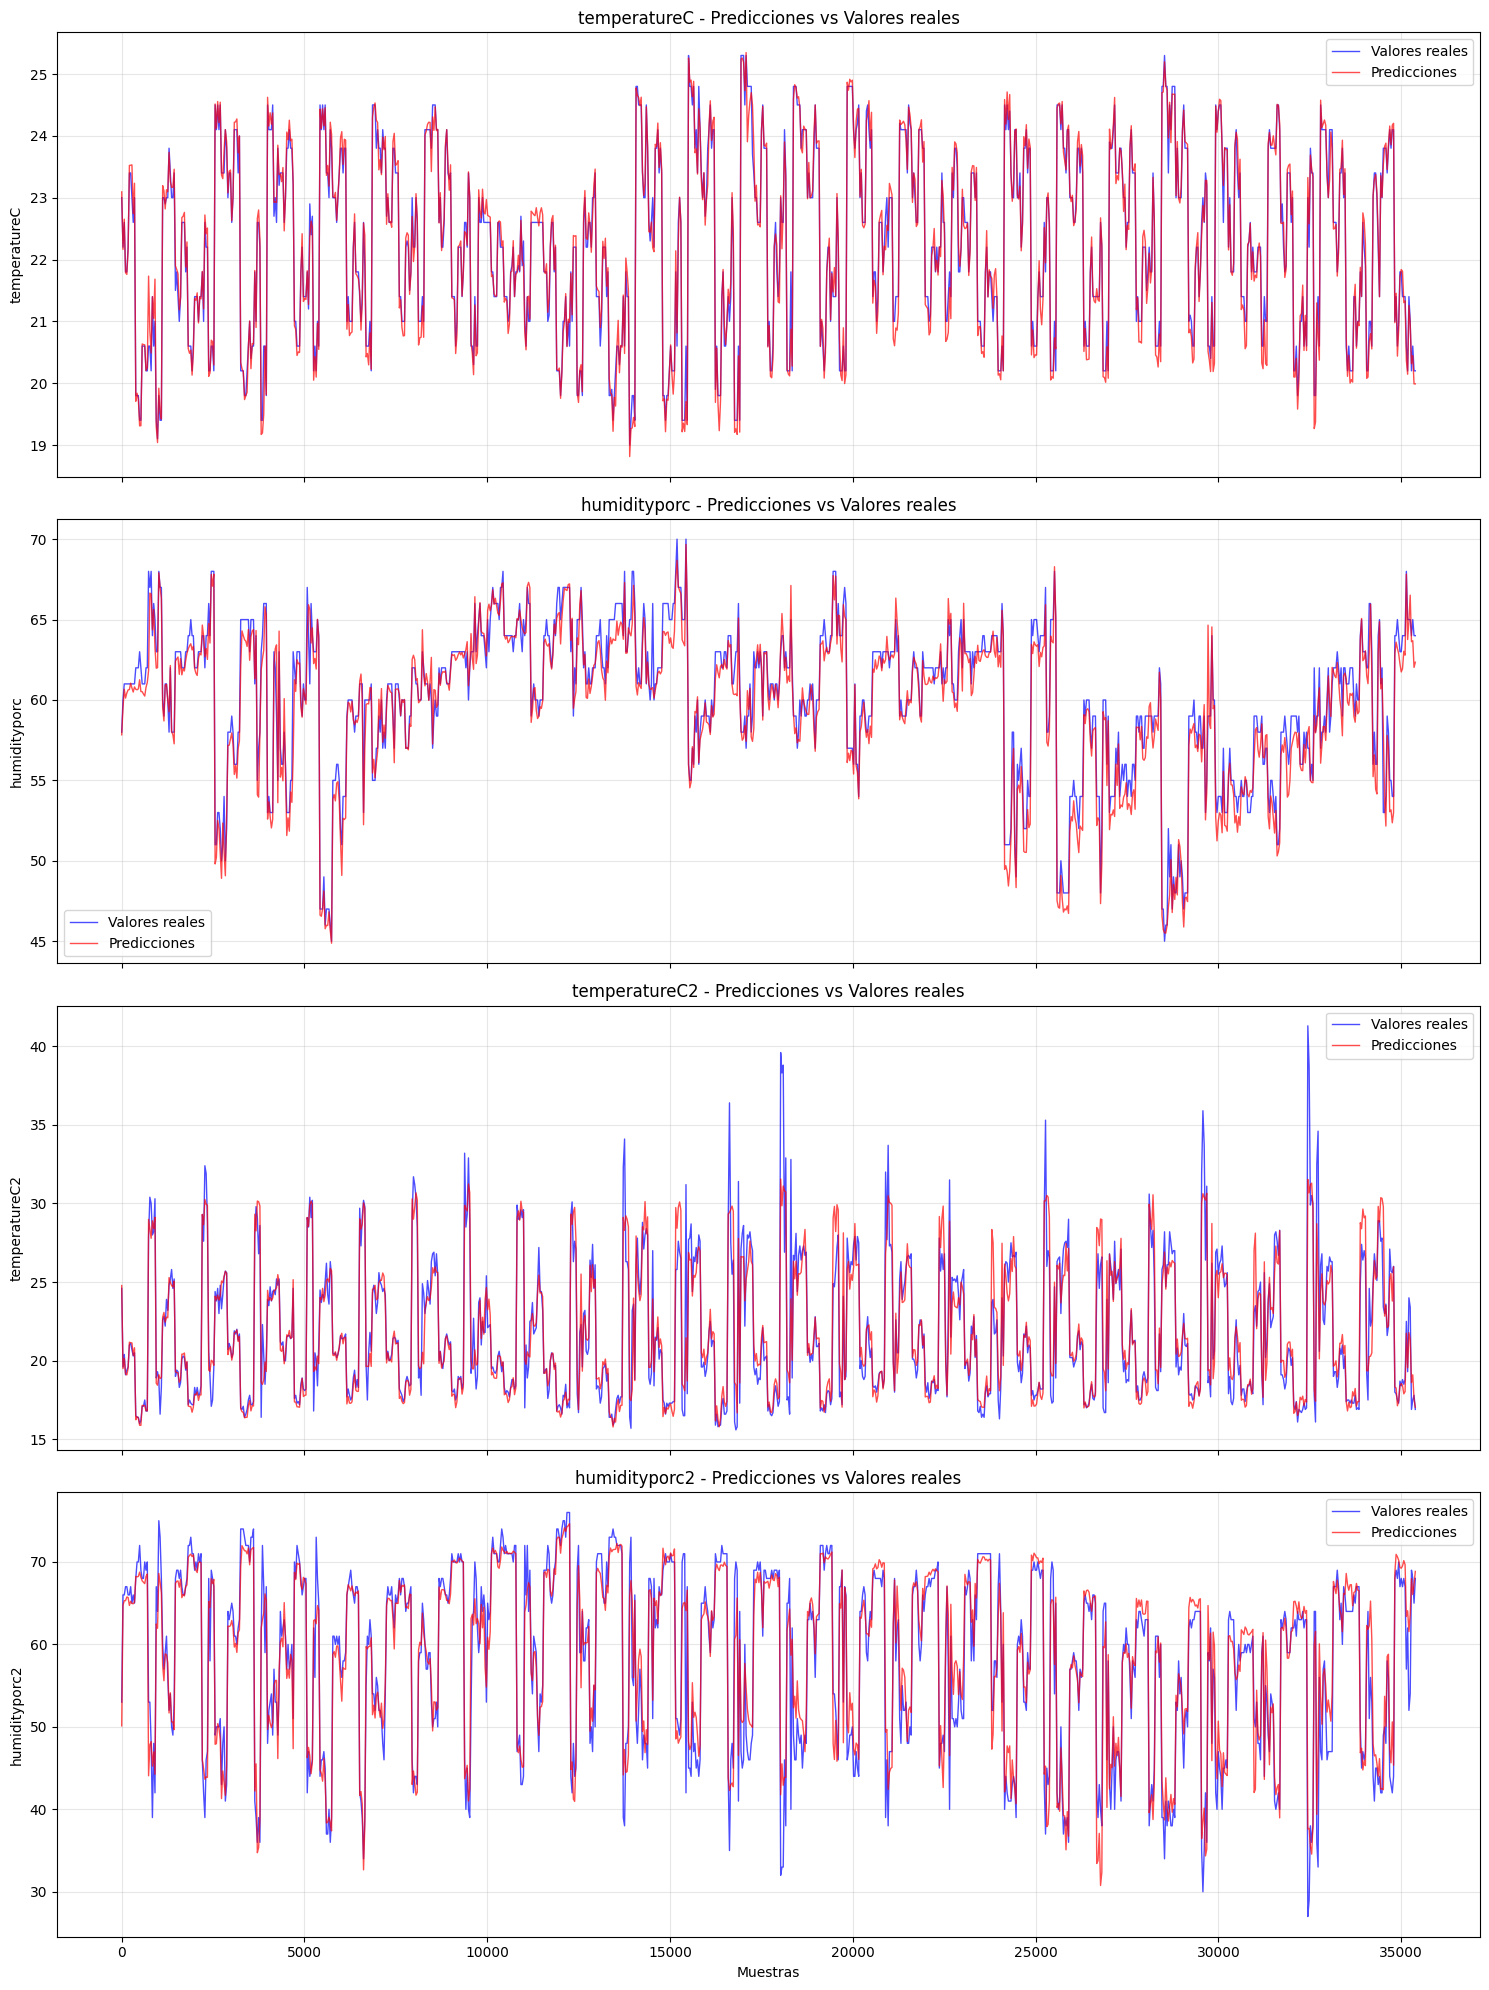

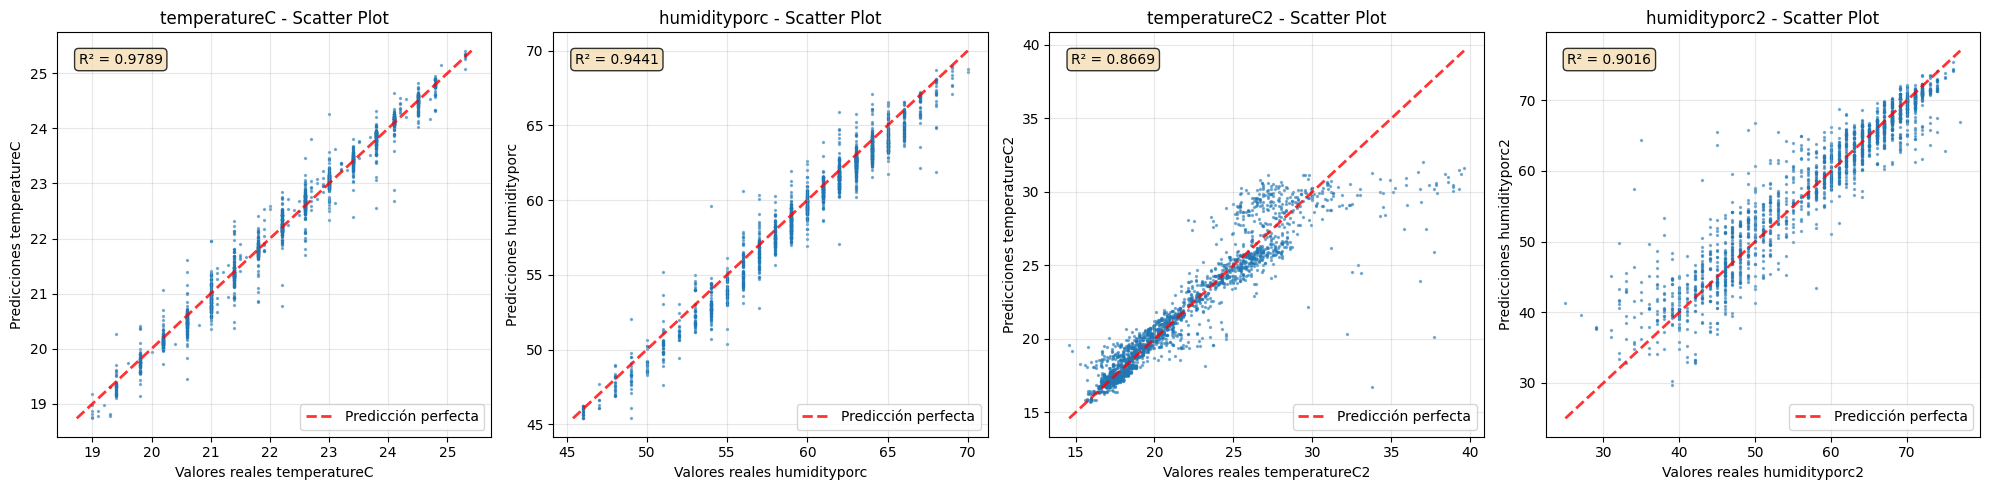

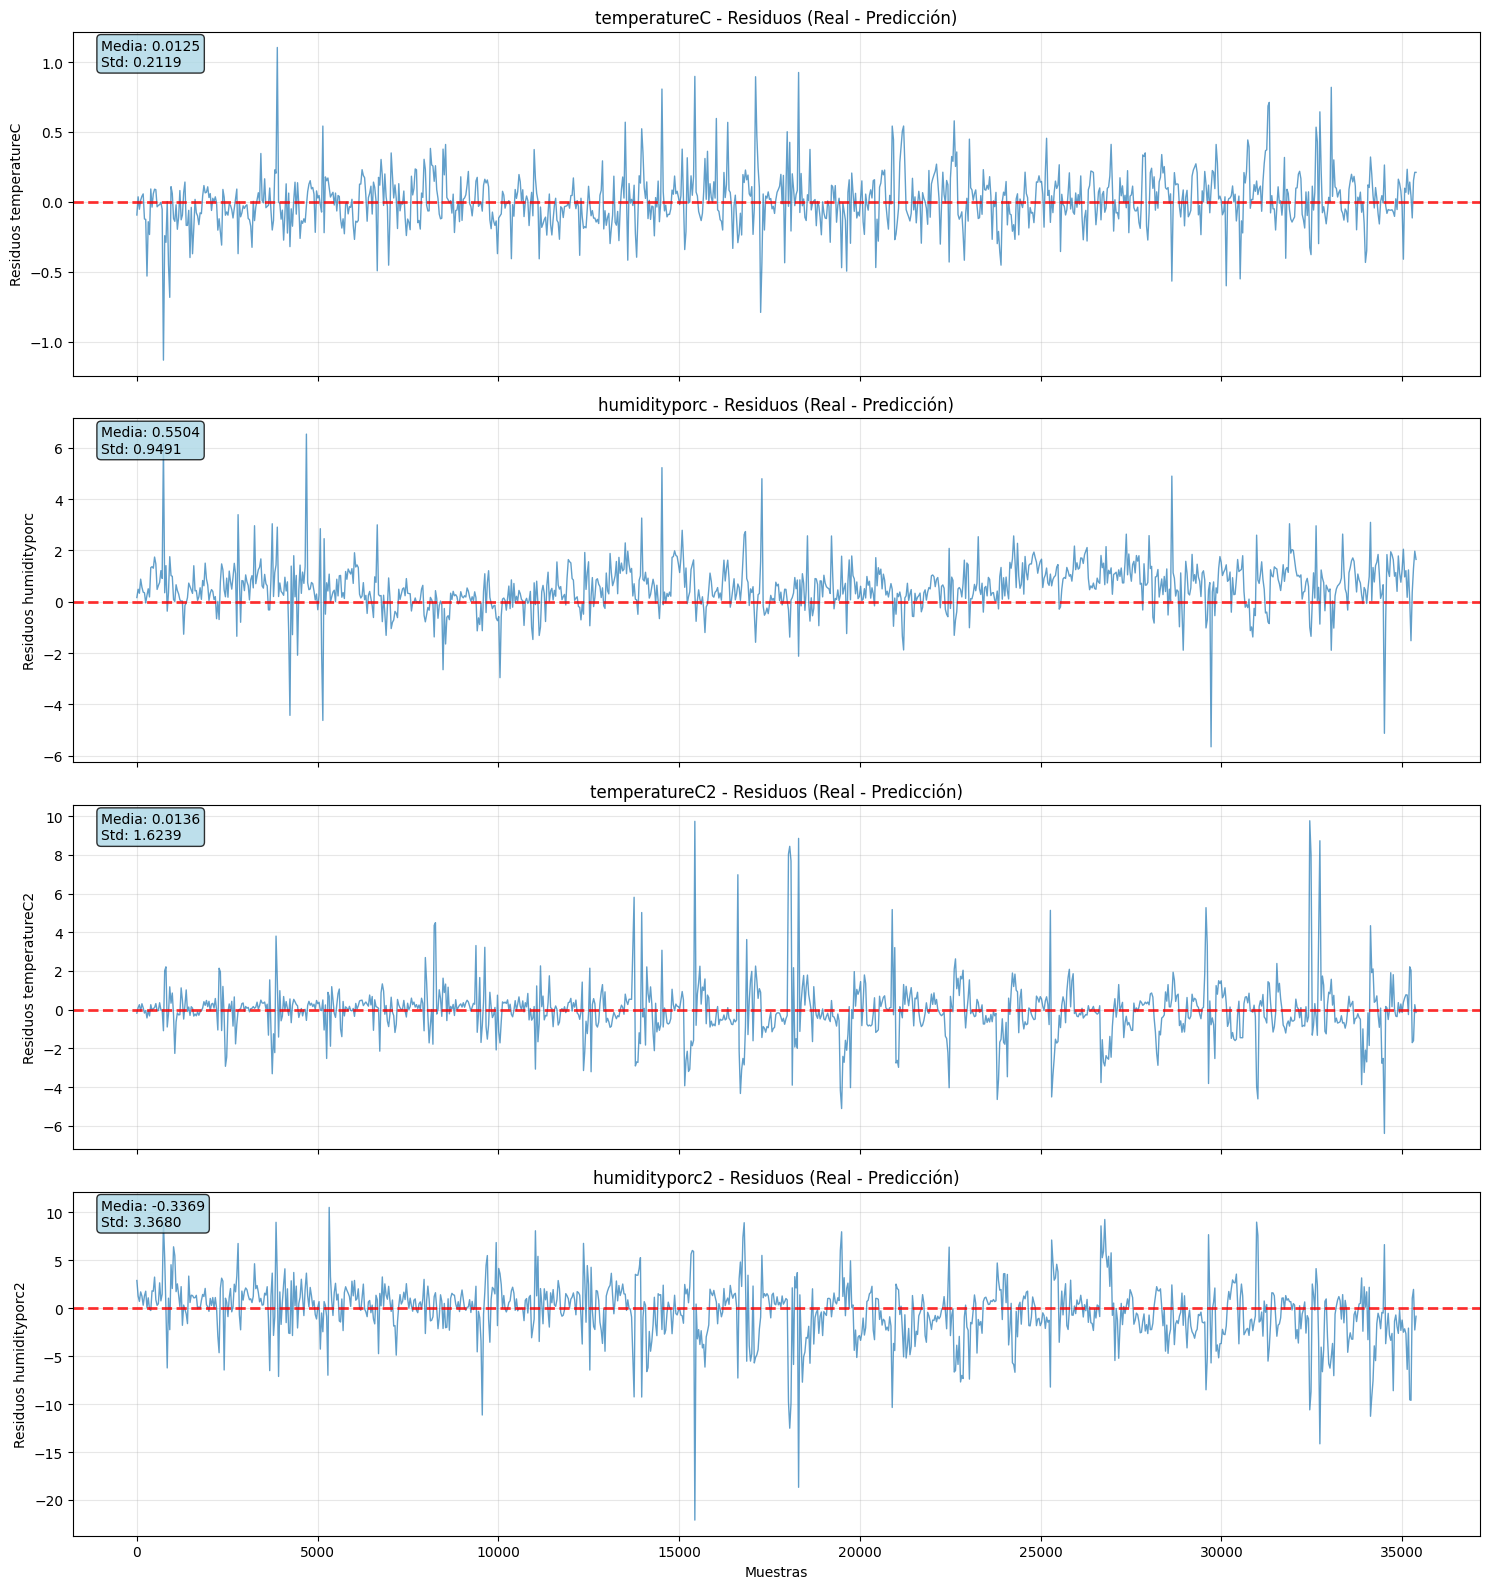

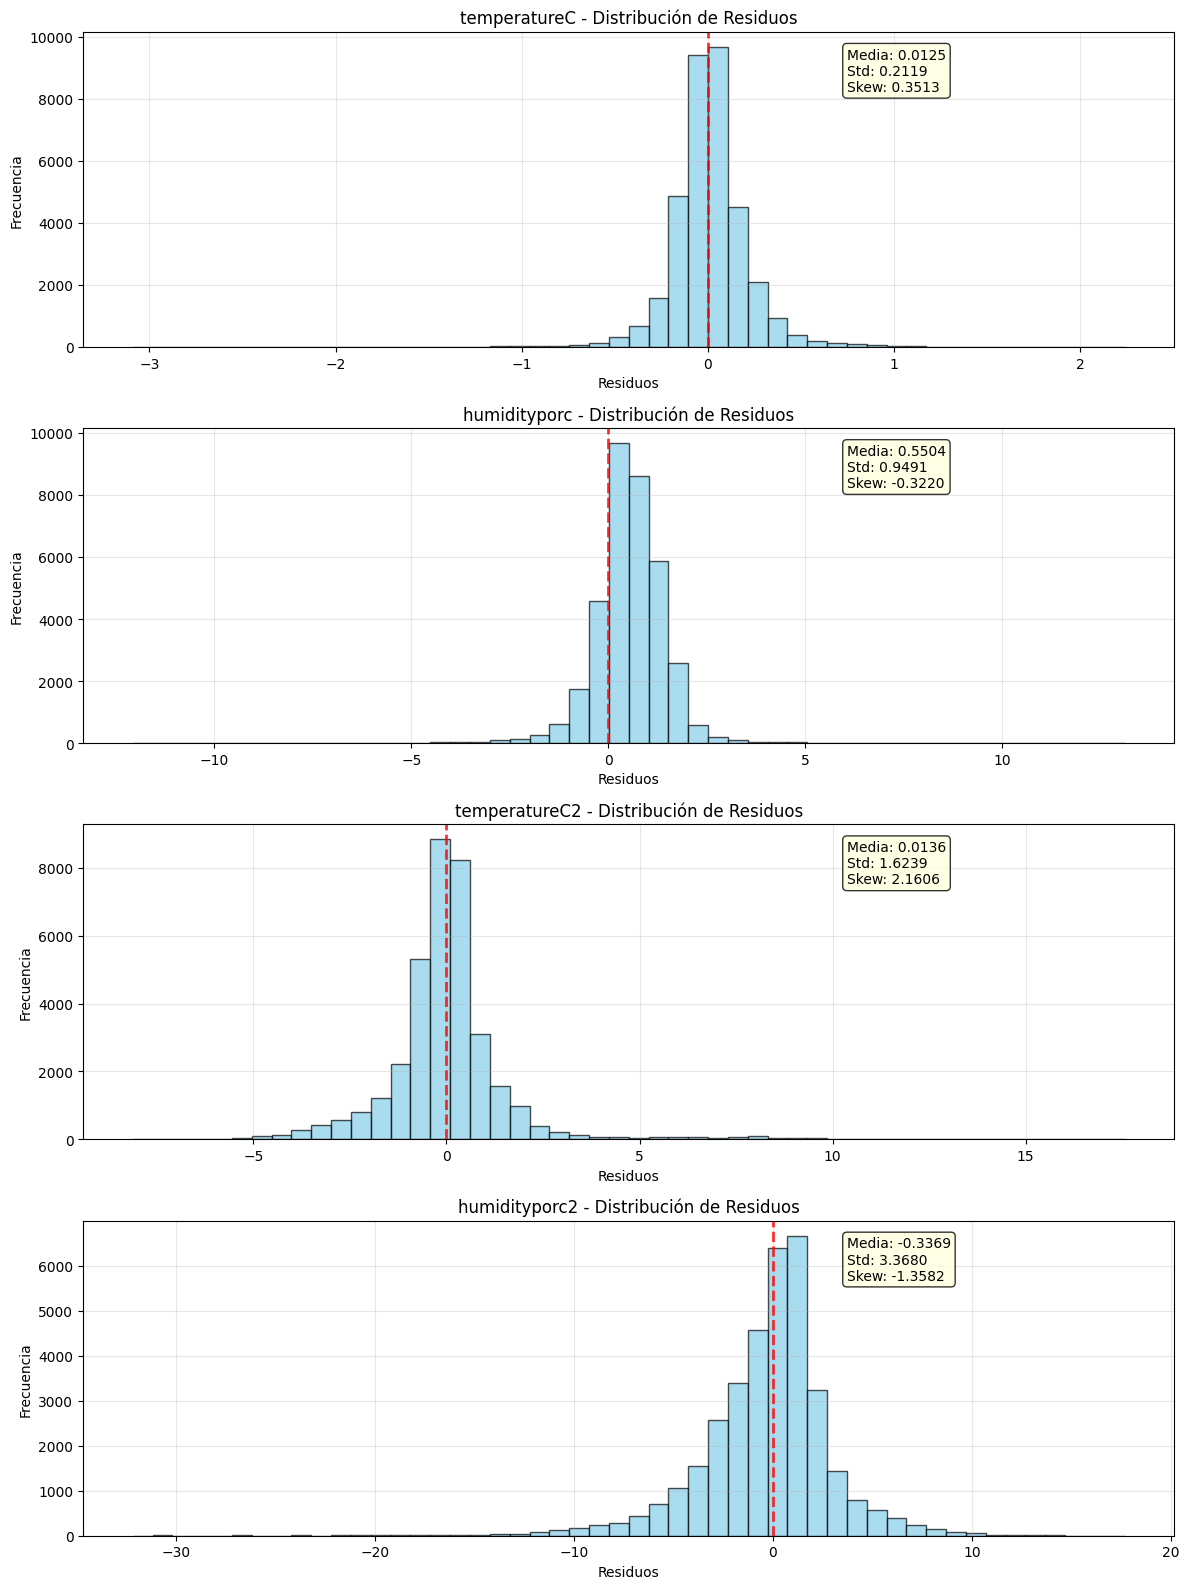

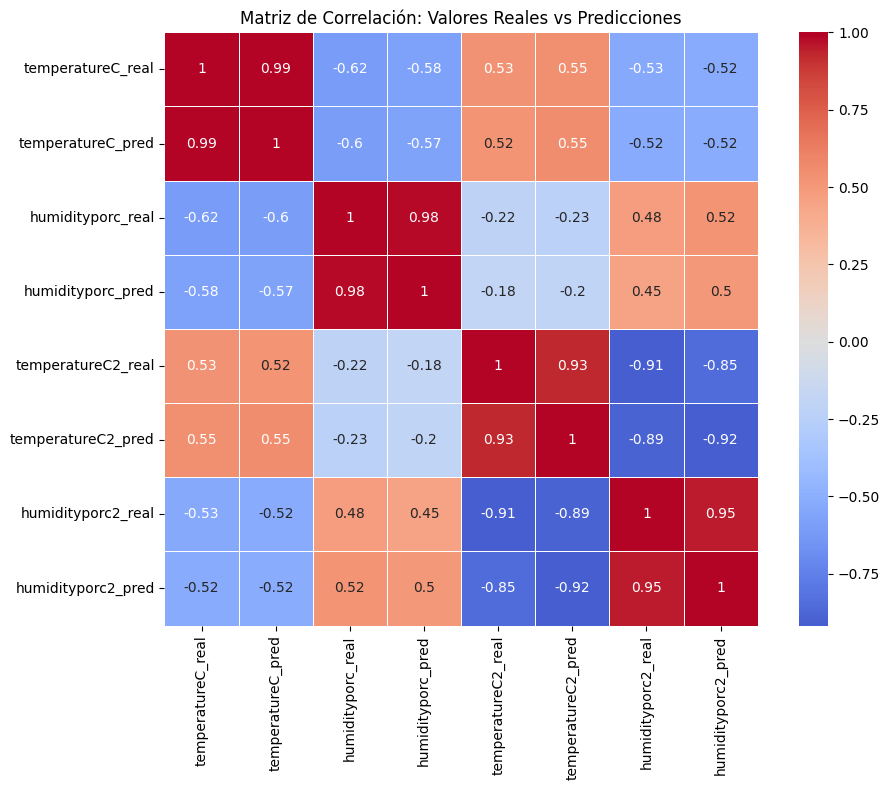

In [8]:
# ==============================
# FUNCIÓN DE EVALUACIÓN ADAPTADA PARA CONV1D
# ==============================
import seaborn as sns
def evaluate_model_conv1d(model, X_data_test, X_features_test, y_test, scaler_output, output_features_cols):
    """
    Función de evaluación adaptada para modelo Conv1D

    Args:
        model: Modelo Conv1D entrenado
        X_data_test: Secuencias de datos de prueba (shape: samples, seq_length, features)
        X_features_test: Características temporales de prueba (shape: samples, features)
        y_test: Valores reales de salida normalizados (shape: samples, targets)
        scaler_output: Scaler usado para las variables de salida
        output_features_cols: Lista con nombres de las variables de salida
    """

    print("="*60)
    print("EVALUACIÓN DEL MODELO CONV1D - SENSORES")
    print("="*60)

    # Hacer predicciones con las 2 entradas del modelo Conv1D
    print("Realizando predicciones en conjunto de prueba...")
    y_pred_scaled = model.predict([X_data_test, X_features_test], verbose=0)

    # Invertir la normalización
    print("Invirtiendo normalización...")
    y_pred = scaler_output.inverse_transform(y_pred_scaled)
    y_true = scaler_output.inverse_transform(y_test)

    print(f"Shape de predicciones: {y_pred.shape}")
    print(f"Shape de valores reales: {y_true.shape}")
    print(f"Número de muestras de prueba: {len(y_test)}")
    print(f"Variables objetivo: {output_features_cols}")

    # ==============================
    # CALCULAR Y MOSTRAR MÉTRICAS
    # ==============================

    print("\n" + "="*60)
    print("MÉTRICAS DE RENDIMIENTO")
    print("="*60)

    metrics_summary = []

    for i, target in enumerate(output_features_cols):
        print(f"\nMétricas para {target}:")
        print("-" * 40)

        # Calcular métricas
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])

        # Avoid division by zero in MAPE
        non_zero_mask = np.abs(y_true[:, i]) > 1e-8
        if np.sum(non_zero_mask) > 0:
            mape = np.mean(np.abs((y_true[:, i][non_zero_mask] - y_pred[:, i][non_zero_mask]) /
                                 (y_true[:, i][non_zero_mask] + 1e-8))) * 100
        else:
            mape = float('inf')

        r2 = r2_score(y_true[:, i], y_pred[:, i])

        # Correlación de Pearson
        correlation = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]

        # Estadísticas adicionales
        mean_real = np.mean(y_true[:, i])
        mean_pred = np.mean(y_pred[:, i])
        std_real = np.std(y_true[:, i])
        std_pred = np.std(y_pred[:, i])

        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  MAPE: {mape:.4f}%")
        print(f"  R²: {r2:.4f}")
        print(f"  Correlación: {correlation:.4f}")
        print(f"  Media real vs pred: {mean_real:.4f} vs {mean_pred:.4f}")
        print(f"  Std real vs pred: {std_real:.4f} vs {std_pred:.4f}")

        # Guardar métricas para resumen
        metrics_summary.append({
            'Variable': target,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R²': r2,
            'Correlación': correlation
        })

    # ==============================
    # TABLA RESUMEN DE MÉTRICAS
    # ==============================

    metrics_df = pd.DataFrame(metrics_summary)
    print(f"\n" + "="*60)
    print("TABLA RESUMEN DE MÉTRICAS")
    print("="*60)
    print(metrics_df.round(4))

    # ==============================
    # GRÁFICAS (igual que antes)
    # ==============================

    # GRÁFICA 1: PREDICCIONES VS VALORES REALES
    fig, axes = plt.subplots(len(output_features_cols), 1, figsize=(15, 5 * len(output_features_cols)), sharex=True)

    if len(output_features_cols) == 1:
        axes = [axes]

    for i, target in enumerate(output_features_cols):
        sample_indices = np.arange(len(y_true[:, i]))
        max_samples = 1000
        if len(sample_indices) > max_samples:
            step = len(sample_indices) // max_samples
            sample_indices = sample_indices[::step]

        axes[i].plot(sample_indices, y_true[sample_indices, i],
                    label='Valores reales', alpha=0.7, linewidth=1, color='blue')
        axes[i].plot(sample_indices, y_pred[sample_indices, i],
                    label='Predicciones', alpha=0.7, linewidth=1, color='red')
        axes[i].set_title(f'{target} - Predicciones vs Valores reales')
        axes[i].set_ylabel(target)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

    # GRÁFICA 2: SCATTER PLOTS
    fig, axes = plt.subplots(1, len(output_features_cols), figsize=(5 * len(output_features_cols), 5))

    if len(output_features_cols) == 1:
        axes = [axes]

    for i, target in enumerate(output_features_cols):
        if len(y_true) > 2000:
            sample_idx = np.random.choice(len(y_true), 2000, replace=False)
            x_scatter = y_true[sample_idx, i]
            y_scatter = y_pred[sample_idx, i]
        else:
            x_scatter = y_true[:, i]
            y_scatter = y_pred[:, i]

        axes[i].scatter(x_scatter, y_scatter, alpha=0.5, s=2)

        min_val = min(np.min(x_scatter), np.min(y_scatter))
        max_val = max(np.max(x_scatter), np.max(y_scatter))
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2,
                    label='Predicción perfecta')

        axes[i].set_xlabel(f'Valores reales {target}')
        axes[i].set_ylabel(f'Predicciones {target}')
        axes[i].set_title(f'{target} - Scatter Plot')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

        r2_val = r2_score(y_true[:, i], y_pred[:, i])
        axes[i].text(0.05, 0.95, f'R² = {r2_val:.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # GRÁFICA 3: RESIDUOS
    fig, axes = plt.subplots(len(output_features_cols), 1, figsize=(15, 4 * len(output_features_cols)), sharex=True)

    if len(output_features_cols) == 1:
        axes = [axes]

    for i, target in enumerate(output_features_cols):
        residuals = y_true[:, i] - y_pred[:, i]

        sample_indices = np.arange(len(residuals))
        if len(sample_indices) > 1000:
            step = len(sample_indices) // 1000
            sample_indices = sample_indices[::step]

        axes[i].plot(sample_indices, residuals[sample_indices], alpha=0.7, linewidth=1)
        axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.8, linewidth=2)
        axes[i].set_title(f'{target} - Residuos (Real - Predicción)')
        axes[i].set_ylabel(f'Residuos {target}')
        axes[i].grid(True, alpha=0.3)

        mean_residual = np.mean(residuals)
        std_residual = np.std(residuals)
        axes[i].text(0.02, 0.98, f'Media: {mean_residual:.4f}\nStd: {std_residual:.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

    # GRÁFICA 4: HISTOGRAMA DE RESIDUOS
    fig, axes = plt.subplots(len(output_features_cols), 1, figsize=(12, 4 * len(output_features_cols)), sharex=False)

    if len(output_features_cols) == 1:
        axes = [axes]

    for i, target in enumerate(output_features_cols):
        residuals = y_true[:, i] - y_pred[:, i]

        axes[i].hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].axvline(x=0, color='r', linestyle='--', linewidth=2, alpha=0.8)
        axes[i].set_title(f'{target} - Distribución de Residuos')
        axes[i].set_xlabel('Residuos')
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True, alpha=0.3)

        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        axes[i].text(0.7, 0.95, f'Media: {mean_res:.4f}\nStd: {std_res:.4f}\nSkew: {pd.Series(residuals).skew():.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # GRÁFICA 5: MATRIZ DE CORRELACIÓN
    comparison_data = {}
    for i, target in enumerate(output_features_cols):
        comparison_data[f'{target}_real'] = y_true[:, i]
        comparison_data[f'{target}_pred'] = y_pred[:, i]

    comparison_df = pd.DataFrame(comparison_data)
    correlation_matrix = comparison_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Matriz de Correlación: Valores Reales vs Predicciones')
    plt.tight_layout()
    plt.show()

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'metrics_df': metrics_df,
        'residuals': {target: y_true[:, i] - y_pred[:, i] for i, target in enumerate(output_features_cols)}
    }


# ==============================
# USAR LA FUNCIÓN
# ==============================

print("\n" + "="*60)
print("INICIANDO EVALUACIÓN DETALLADA DEL MODELO CONV1D")
print("="*60)

# Evaluar el modelo Conv1D con las 2 entradas correctas
results = evaluate_model_conv1d(model, X_data_test, X_features_test, y_test, scaler_output, output_features_cols)